# Echo Chamber Ratio 2.0 (ECR 2.0) - Full Analysis Pipeline

**Unified notebook** yang menggabungkan seluruh pipeline:
1. **Preprocessing** - Load, clean, dan prepare data dari CSV IndSight
2. **Sentiment -> Probability** - Konversi label sentimen ke distribusi probabilitas
3. **Kalibrasi** - Probability calibration (Isotonic Regression per-class)
4. **Graph Building** - Bangun graf interaksi (reply, retweet, mention)
5. **User Leaning** - Estimasi kecenderungan user berdasarkan probabilitas terkalibrasi
6. **Community Detection** - Deteksi komunitas (Leiden / Louvain)
7. **ECR 2.0 Computation** - Hitung Echo Chamber Ratio (intra/inter agreement)
8. **Diffusion Bias (IC)** - Simulasi Independent Cascade
9. **Community Analysis** - Pro vs Contra, central users, bridge users, topic shifts
10. **Visualisasi** - Grafik komprehensif dari seluruh hasil analisis

---
**Dependencies:** `pandas numpy networkx igraph leidenalg scikit-learn matplotlib seaborn tqdm emoji`

## 0. Setup & Imports

In [40]:
from __future__ import annotations

import math
import random
import copy
import re
import warnings
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Tuple
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# sklearn
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, brier_score_loss)

# scipy
from scipy.optimize import minimize_scalar
from scipy import stats as scipy_stats

try:
    import igraph as ig
    import leidenalg as la
    _HAS_LEIDEN = True
except ImportError:
    _HAS_LEIDEN = False

try:
    from infomap import Infomap
    _HAS_INFOMAP = True
except ImportError:
    _HAS_INFOMAP = False

try:
    import emoji
    _HAS_EMOJI = True
except ImportError:
    _HAS_EMOJI = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("LIBRARY STATUS")
print(f"  Leiden    : {_HAS_LEIDEN}")
print(f"  Infomap   : {_HAS_INFOMAP}")
print(f"  emoji     : {_HAS_EMOJI}")
print(f"  scipy     : True")
print(f"  sklearn   : True")

LIBRARY STATUS
  Leiden    : True
  Infomap   : True
  emoji     : True
  scipy     : True
  sklearn   : True


---
## 1. Preprocessing

Load data dari file CSV yang sudah dibersihkan (hapus URL, mention, hashtag, emoji), 
hapus duplikat, dan pilih kolom yang relevan.

In [41]:
# 1a. Load data + helper functions

# Helper functions
def normalize_id(uid):
    """Normalisasi user ID ke integer string yang konsisten.
    '1.342e+18' -> '1342808971912998912', '2754745839.0' -> '2754745839'"""
    if pd.isna(uid): return None
    uid = str(uid).strip()
    if not uid or uid in ('nan', 'None', ''): return None
    try: return str(int(float(uid)))
    except (ValueError, OverflowError): return uid

def parse_mentioned(raw):
    # Parse kolom mentioned: (name,USERNAME)//(id,USERID) pairs.
    if not raw or str(raw) == 'nan': return []
    pattern = r'\(name,([^)]+)\)//\(id,([^)]+)\)'
    return [{'username': m[0].strip(), 'user_id': normalize_id(m[1].strip())}
            for m in re.findall(pattern, str(raw)) if normalize_id(m[1].strip())]

# Baca data
data = pd.read_csv("total_data_cleaned_indonesia_gelap.csv", low_memory=False)
print(f"Shape: {data.shape}")
data['from_id'] = data['from_id'].apply(normalize_id)

# Build username_map dari SEMUA sumber
username_map = {}

# Sumber 1: from_username 
_u = data[['from_id','from_username']].dropna(subset=['from_username']).drop_duplicates('from_id')
username_map.update(dict(zip(_u['from_id'], _u['from_username'])))
print(f"Username dari data utama: {len(username_map):,}")

# Sumber 2: kolom mentioned -> (name,USERNAME)//(id,USERID)
n_added = 0
for raw in data['mentioned'].dropna():
    for item in parse_mentioned(raw):
        if item['user_id'] and item['user_id'] not in username_map:
            username_map[item['user_id']] = item['username']
            n_added += 1
print(f"Username dari mentioned: +{n_added:,} baru (total: {len(username_map):,})")

print(f"\nTotal username_map: {len(username_map):,}")
for uid, uname in list(username_map.items())[:5]:
    print(f"{uid} -> {uname}")

data.head()

Shape: (600270, 54)
Username dari data utama: 208,345
Username dari mentioned: +3,542 baru (total: 211,887)

Total username_map: 211,887
7433682716006499328 -> laskargarudaperkasa1
7247119596988285952 -> hikmal9987
6688872989197157376 -> garuda273
7156225694623204352 -> timothy_mindset07
7277782110633821184 -> erev72662812


,original_id,date_created,resource_type,specific_resource_type,specific_type,post_type,stream_type,object_name,object_content,from_id,...,object_title,object_group,sentiment_confidence_level,view,creation_time,coauthor_with,user_rating,retweet_original_id_timestamp,label,cleaned_text
0,7544582076696300856,31/08/2025 10.11.51,social_media,tiktok,video,talk,keyword,indonesia gelap,indonesia gelap,7433682716006499328,...,indonesia gelap,custom-report-isu-nasional #Indonesiagelap,0.549426,4315,04/09/2025 11.02.14,NaN,NaN,NaN,NaN,INDONESIA GELAP INDONESIA MENCEKAM HIMBAUAN: B...
1,7544540728753308434,31/08/2025 07.31.27,social_media,tiktok,comment,talk,keyword,indonesia gelap,indonesia gelap,7247119596988285952,...,indonesia gelap,custom-report-isu-nasional #Indonesiagelap,0.200000,0,30/09/2025 23.23.43,NaN,NaN,NaN,NaN,Indonesia gelap
2,7544292577526465288,30/08/2025 15.28.26,social_media,tiktok,comment,talk,keyword,indonesia gelap,indonesia gelap,6688872989197157376,...,indonesia gelap,custom-report-isu-nasional #Indonesiagelap,0.200000,0,02/10/2025 16.18.07,NaN,NaN,NaN,NaN,di bilang Indonesia gelap ngk percaya
3,7543512511645434642,28/08/2025 13.01.25,social_media,tiktok,comment,talk,keyword,indonesia gelap,indonesia gelap,7156225694623204352,...,indonesia gelap,custom-report-isu-nasional #Indonesiagelap,0.200000,0,07/10/2025 13.37.57,NaN,NaN,NaN,NaN,bang kemana lu saat Indonesia butuh aktor Indo...
4,7543135845056283410,27/08/2025 12.39.43,social_media,tiktok,comment,talk,keyword,indonesia gelap,indonesia gelap,7277782110633821184,...,indonesia gelap,custom-report-isu-nasional #Indonesiagelap,0.200000,0,07/10/2025 13.37.57,NaN,NaN,NaN,NaN,"""Indonesia gelap"""


In [42]:
def get_username(user_id):
    # Lookup username. Return @ID jika tidak ditemukan.
    nid = normalize_id(user_id)
    uname = username_map.get(nid)
    return uname if uname else (f"@{nid}" if nid else f"@{user_id}")

# 1d. Pilih kolom & normalize semua ID
REQUIRED_COLS = [
    'original_id', 'from_id', 'from_username', 'cleaned_text',
    'final_sentiment', 'sentiment_confidence_level',
    'reply_to_user_id', 'retweet_from_user_id', 'mentioned',
]
available = [c for c in REQUIRED_COLS if c in data.columns]
df = data[available].copy()
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']

#  Language Detection: filter hanya teks Bahasa Indonesia
from langdetect import detect, LangDetectException

def is_indonesian(text):
    # Return True jika teks terdeteksi sebagai Bahasa Indonesia.
    try:
        return detect(text) == 'id'
    except LangDetectException:
        return False

print(f"Before language filter: {df.shape}")
tqdm.pandas(desc="Detecting language")
df = df[df['cleaned_text'].progress_apply(is_indonesian)].reset_index(drop=True)
print(f"After language filter (Indonesian only): {df.shape}")

# Normalize SEMUA kolom ID agar konsisten
for id_col in ['from_id', 'reply_to_user_id', 'retweet_from_user_id']:
    if id_col in df.columns:
        df[id_col] = df[id_col].apply(normalize_id)

df['sentiment_confidence_level'] = pd.to_numeric(df['sentiment_confidence_level'], errors='coerce').fillna(0.5).clip(0.0, 1.0)

# Test username lookup
print("Username lookup test:")
for sid in df['from_id'].dropna().unique()[:5]:
    print(f"{sid} -> {get_username(sid)}")
    
print(f"\nFinal shape: {df.shape}")
print(df['final_sentiment'].value_counts())

Before language filter: (521143, 9)


Detecting language: 100%|██████████| 521143/521143 [11:35<00:00, 749.35it/s] 


After language filter (Indonesian only): (338436, 9)
Username lookup test:
7433682716006499328 -> laskargarudaperkasa1
7247119596988285952 -> hikmal9987
6688872989197157376 -> garuda273
7156225694623204352 -> timothy_mindset07
7277782110633821184 -> erev72662812

Final shape: (338436, 9)
final_sentiment
negative    210013
neutral     107143
positive     21280
Name: count, dtype: int64


---
## 2. Konversi Sentimen ke Distribusi Probabilitas

Mengubah label sentimen kategorik + confidence score menjadi distribusi 
probabilitas `[p_neg, p_neu, p_pos]`.

**Formula:**
- `p_main = 1/3 + confidence × (1 - 1/3)`
- `p_other = (1 - p_main) / 2`

In [43]:
def convert_sentiment_to_probabilities(
    df: pd.DataFrame,
    sentiment_col: str = "final_sentiment",
    confidence_col: str = "sentiment_confidence_level",
) -> pd.DataFrame:
    result = df.copy()

    sentiment_map = {
        'negative': 0, 'neg': 0, 'contra': 0,
        'neutral': 1, 'neu': 1,
        'positive': 2, 'pos': 2, 'pro': 2,
    }

    sentiments = result[sentiment_col].astype(str).str.lower().apply(
        lambda x: sentiment_map.get(x, 1)
    ).values

    confidences = result[confidence_col].fillna(0.5).clip(0.0, 1.0).values

    n = len(result)
    # Vectorized: no Python for-loop (faster & cleaner)
    p_main  = (1.0/3.0) + confidences * (2.0/3.0)   # shape (n,)
    p_other = (1.0 - p_main) / 2.0                   # shape (n,)

    proba = np.tile(p_other[:, None], (1, 3))         # fill all cols with p_other
    proba[np.arange(n), sentiments] = p_main          # overwrite main class

    # Renormalise for floating-point safety
    proba = proba / proba.sum(axis=1, keepdims=True)

    result['p_neg'] = proba[:, 0]
    result['p_neu'] = proba[:, 1]
    result['p_pos'] = proba[:, 2]

    return result

df = convert_sentiment_to_probabilities(df)

print("Distribusi Probabilitas (sampel 10 baris):")
print(df[['final_sentiment', 'sentiment_confidence_level', 'p_neg', 'p_neu', 'p_pos']].head(10))

# Statistik individual per kolom - menunjukkan variasi bermakna (std > 0)
print("\nStatistik distribusi probabilitas per kelas:")
print(df[['p_neg', 'p_neu', 'p_pos']].describe().round(4))

# Sanity check baris: sum harus ~1.0
# Catatan: std row-sum = 0 adalah BENAR secara matematis - formula + normalisasi
# menjamin setiap baris menjumlahkan tepat 1.0 (bukan bug).
row_sums = df[['p_neg', 'p_neu', 'p_pos']].sum(axis=1)
print(f"\nRow-sum sanity check: min={row_sums.min():.8f}, max={row_sums.max():.8f}, mean={row_sums.mean():.8f}")

print(f"\nDistribusi confidence level:")
print(df['sentiment_confidence_level'].describe().round(4))


Distribusi Probabilitas (sampel 10 baris):
  final_sentiment  sentiment_confidence_level     p_neg     p_neu     p_pos
0         neutral                    0.549426  0.150191  0.699617  0.150191
1         neutral                    0.200000  0.266667  0.466667  0.266667
2         neutral                    0.200000  0.266667  0.466667  0.266667
3         neutral                    0.200000  0.266667  0.466667  0.266667
4         neutral                    0.200000  0.266667  0.466667  0.266667
5         neutral                    0.200000  0.266667  0.466667  0.266667
6         neutral                    0.200000  0.266667  0.466667  0.266667
7         neutral                    0.200000  0.266667  0.466667  0.266667
8         neutral                    0.200000  0.266667  0.466667  0.266667
9         neutral                    0.558226  0.147258  0.705484  0.147258

Statistik distribusi probabilitas per kelas:
             p_neg        p_neu        p_pos
count  338436.0000  338436.000

---
## 3. Kalibrasi Probabilitas (Cross-Validated)

**Perbaikan dari versi sebelumnya**: Kalibrasi sebelumnya bersifat sirkular (fit & transform pada data yang sama). Sekarang menggunakan **Stratified K-Fold CV** agar calibrator di-fit pada training fold dan diterapkan pada validation fold.

**3 metode dibandingkan**:
1. **Isotonic Regression (CV)** - non-parametric, per-class OvR
2. **Platt/Sigmoid Scaling (CV)** - logistic regression per-class
3. **Temperature Scaling** - single parameter T pada logits, dioptimasi via NLL

**Metrik evaluasi**: ECE (Expected Calibration Error), Log-Loss, Brier Score
Metode dengan **ECE terendah** dipilih untuk pipeline selanjutnya.

In [44]:
# 3a. Helper functions for calibration

def compute_ece(y_true, y_prob, n_bins=15):
    """Expected Calibration Error."""
    if y_prob.ndim == 2:
        confidences = np.max(y_prob, axis=1)
        predictions = np.argmax(y_prob, axis=1)
        accuracies = (predictions == y_true).astype(float)
    else:
        confidences = y_prob
        accuracies = y_true.astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_accs = np.zeros(n_bins)
    bin_confs = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins)

    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        mask = (confidences >= lo) & (confidences <= hi) if i == n_bins - 1 else (confidences >= lo) & (confidences < hi)
        count = mask.sum()
        bin_counts[i] = count
        if count > 0:
            bin_accs[i] = accuracies[mask].mean()
            bin_confs[i] = confidences[mask].mean()

    ece = float(np.sum(np.abs(bin_accs - bin_confs) * bin_counts) / max(len(y_true), 1))
    return ece, bin_accs, bin_confs, bin_counts


def _sentiment_to_class_idx(series, sent_map):
    """Convert sentiment labels to class indices (0, 1, 2). Pandas 3.0 compatible."""
    return series.astype(str).str.lower().apply(lambda x: sent_map.get(x, 1)).astype(int).values


def calibrate_cv(df, prob_cols, label_col, method='isotonic', cv_folds=5, random_state=42):
    """Calibrate probabilities using stratified K-Fold CV."""
    sent_map = {'negative': 0, 'neg': 0, 'contra': 0,
                'neutral': 1, 'neu': 1,
                'positive': 2, 'pos': 2, 'pro': 2}
    y_class = _sentiment_to_class_idx(df[label_col], sent_map)
    P = df[list(prob_cols)].values.astype(float)
    P = np.clip(P, 1e-12, 1.0)
    P = P / P.sum(axis=1, keepdims=True)

    P_cal = np.zeros_like(P)
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    for train_idx, val_idx in skf.split(P, y_class):
        P_train, y_train = P[train_idx], y_class[train_idx]
        P_val = P[val_idx]

        for k in range(3):
            y_bin = (y_train == k).astype(float)
            if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
                P_cal[val_idx, k] = P_val[:, k]
                continue
            if method == 'isotonic':
                cal = IsotonicRegression(out_of_bounds='clip')
                cal.fit(P_train[:, k], y_bin)
                P_cal[val_idx, k] = cal.transform(P_val[:, k])
            elif method == 'sigmoid':
                lr = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
                lr.fit(P_train[:, k].reshape(-1, 1), y_bin)
                P_cal[val_idx, k] = lr.predict_proba(P_val[:, k].reshape(-1, 1))[:, 1]

    P_cal = np.clip(P_cal, 1e-12, 1.0)
    P_cal = P_cal / P_cal.sum(axis=1, keepdims=True)

    Y_oh = np.eye(3)[y_class]
    ece, _, _, _ = compute_ece(y_class, P_cal)
    ll = -np.mean(np.sum(Y_oh * np.log(P_cal + 1e-12), axis=1))
    brier = np.mean(np.sum((Y_oh - P_cal) ** 2, axis=1))

    return P_cal, {'method': method, 'ece': ece, 'log_loss': ll, 'brier_score': brier}


def temperature_scaling_fit(y_class, P):
    """Fit temperature parameter T minimizing NLL. T >= 1.0 only (softening, not sharpening)."""
    eps = 1e-8
    logits = np.log(np.clip(P, eps, 1 - eps))
    Y_oh = np.eye(3)[y_class]

    def nll(T):
        z = logits / max(T, 1e-4)
        z = z - z.max(axis=1, keepdims=True)
        e = np.exp(z)
        Q = e / e.sum(axis=1, keepdims=True)
        return -np.mean(np.sum(Y_oh * np.log(Q + 1e-12), axis=1))

    # Bounds start at 1.0 so T can only soften (not sharpen) the distribution
    result = minimize_scalar(nll, bounds=(1.0, 10.0), method='bounded')
    T_opt = result.x

    z = logits / T_opt
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    P_cal = e / e.sum(axis=1, keepdims=True)

    ece, _, _, _ = compute_ece(y_class, P_cal)
    ll = -np.mean(np.sum(Y_oh * np.log(P_cal + 1e-12), axis=1))
    brier = np.mean(np.sum((Y_oh - P_cal) ** 2, axis=1))

    return P_cal, T_opt, {'method': 'temperature', 'ece': ece, 'log_loss': ll, 'brier_score': brier, 'T': T_opt}


# 3b. Run calibration comparison (3 methods)

sent_map = {'negative': 0, 'neg': 0, 'contra': 0,
            'neutral': 1, 'neu': 1,
            'positive': 2, 'pos': 2, 'pro': 2}
y_class = _sentiment_to_class_idx(df['final_sentiment'], sent_map)
P_orig = df[['p_neg', 'p_neu', 'p_pos']].values.astype(float)
P_orig = np.clip(P_orig, 1e-12, 1.0)
P_orig = P_orig / P_orig.sum(axis=1, keepdims=True)

# Uncalibrated metrics
Y_oh = np.eye(3)[y_class]
ece_orig, _, _, _ = compute_ece(y_class, P_orig)
ll_orig = -np.mean(np.sum(Y_oh * np.log(P_orig + 1e-12), axis=1))
brier_orig = np.mean(np.sum((Y_oh - P_orig) ** 2, axis=1))
uncal_metrics = {'method': 'uncalibrated', 'ece': ece_orig, 'log_loss': ll_orig, 'brier_score': brier_orig}

print("=== KALIBRASI PROBABILITAS (Cross-Validated) ===\n")

# Method 1: Isotonic CV
P_iso, iso_metrics = calibrate_cv(df, ('p_neg', 'p_neu', 'p_pos'), 'final_sentiment', method='isotonic')
print(f"Isotonic (CV)   : ECE={iso_metrics['ece']:.4f}, LogLoss={iso_metrics['log_loss']:.4f}, Brier={iso_metrics['brier_score']:.4f}")

# Method 2: Sigmoid/Platt CV
P_sig, sig_metrics = calibrate_cv(df, ('p_neg', 'p_neu', 'p_pos'), 'final_sentiment', method='sigmoid')
print(f"Sigmoid (CV)    : ECE={sig_metrics['ece']:.4f}, LogLoss={sig_metrics['log_loss']:.4f}, Brier={sig_metrics['brier_score']:.4f}")

# Method 3: Temperature Scaling (T >= 1.0, softening only)
P_temp, T_opt, temp_metrics = temperature_scaling_fit(y_class, P_orig)
print(f"Temperature (T={T_opt:.3f}): ECE={temp_metrics['ece']:.4f}, LogLoss={temp_metrics['log_loss']:.4f}, Brier={temp_metrics['brier_score']:.4f}")

print(f"\nUncalibrated    : ECE={uncal_metrics['ece']:.4f}, LogLoss={uncal_metrics['log_loss']:.4f}, Brier={uncal_metrics['brier_score']:.4f}")

# Comparison table
cal_comparison = pd.DataFrame([uncal_metrics, iso_metrics, sig_metrics, temp_metrics])
cal_comparison = cal_comparison[['method', 'ece', 'log_loss', 'brier_score']]
print("\n=== PERBANDINGAN METODE KALIBRASI ===")
print(cal_comparison.to_string(index=False))

# Select best method (lowest ECE)
best_method = cal_comparison.loc[cal_comparison['ece'].idxmin(), 'method']
print(f"\nMetode terbaik (lowest ECE): {best_method}")

# Apply best calibration
if best_method == 'isotonic':
    P_best = P_iso
elif best_method == 'sigmoid':
    P_best = P_sig
elif best_method == 'temperature':
    P_best = P_temp
else:
    P_best = P_orig

df['p_neg_cal'] = P_best[:, 0]
df['p_neu_cal'] = P_best[:, 1]
df['p_pos_cal'] = P_best[:, 2]

cal_labels = np.array(['negative', 'neutral', 'positive'])
df['calibrated_sentiment'] = cal_labels[np.argmax(P_best, axis=1)]
df['calibrated_confidence'] = np.max(P_best, axis=1)
df['sentiment_changed'] = (df['calibrated_sentiment'] != df['final_sentiment'])

n_changed = df['sentiment_changed'].sum()
print(f"\nSentimen berubah setelah kalibrasi: {n_changed:,} ({100*n_changed/len(df):.2f}%)")

=== KALIBRASI PROBABILITAS (Cross-Validated) ===

Isotonic (CV)   : ECE=0.0000, LogLoss=0.0001, Brier=0.0000
Sigmoid (CV)    : ECE=0.0021, LogLoss=0.0023, Brier=0.0004
Temperature (T=1.000): ECE=0.2413, LogLoss=0.2999, Brier=0.1216

Uncalibrated    : ECE=0.2413, LogLoss=0.2999, Brier=0.1216

=== PERBANDINGAN METODE KALIBRASI ===
      method          ece  log_loss  brier_score
uncalibrated 2.413162e-01  0.299874     0.121561
    isotonic 6.858717e-08  0.000112     0.000035
     sigmoid 2.116068e-03  0.002275     0.000400
 temperature 2.413174e-01  0.299876     0.121562

Metode terbaik (lowest ECE): isotonic

Sentimen berubah setelah kalibrasi: 6 (0.00%)


=== DAMPAK KALIBRASI PER TINGKAT MINIMUM CONFIDENCE ===

 Min Conf |     N Rows |  N Changed |  % Changed |  ECE Sblm |  ECE Sdh
------------------------------------------------------------------------
  >= 0.2   |    337,250 |          0 |      0.00% |    0.2410 |   0.0000
  >= 0.5   |    262,222 |          0 |      0.00% |    0.1797 |   0.0000
  >= 0.7   |    144,398 |          0 |      0.00% |    0.1046 |   0.0000
  >= 0.8   |    106,928 |          0 |      0.00% |    0.0830 |   0.0000
  >= 0.9   |     45,126 |          0 |      0.00% |    0.0479 |   0.0000
  >= 1.0   |          0 |          - |          - |         - | terlalu sedikit data

Saved: ecr_analysis_results/calibration_comparison.csv


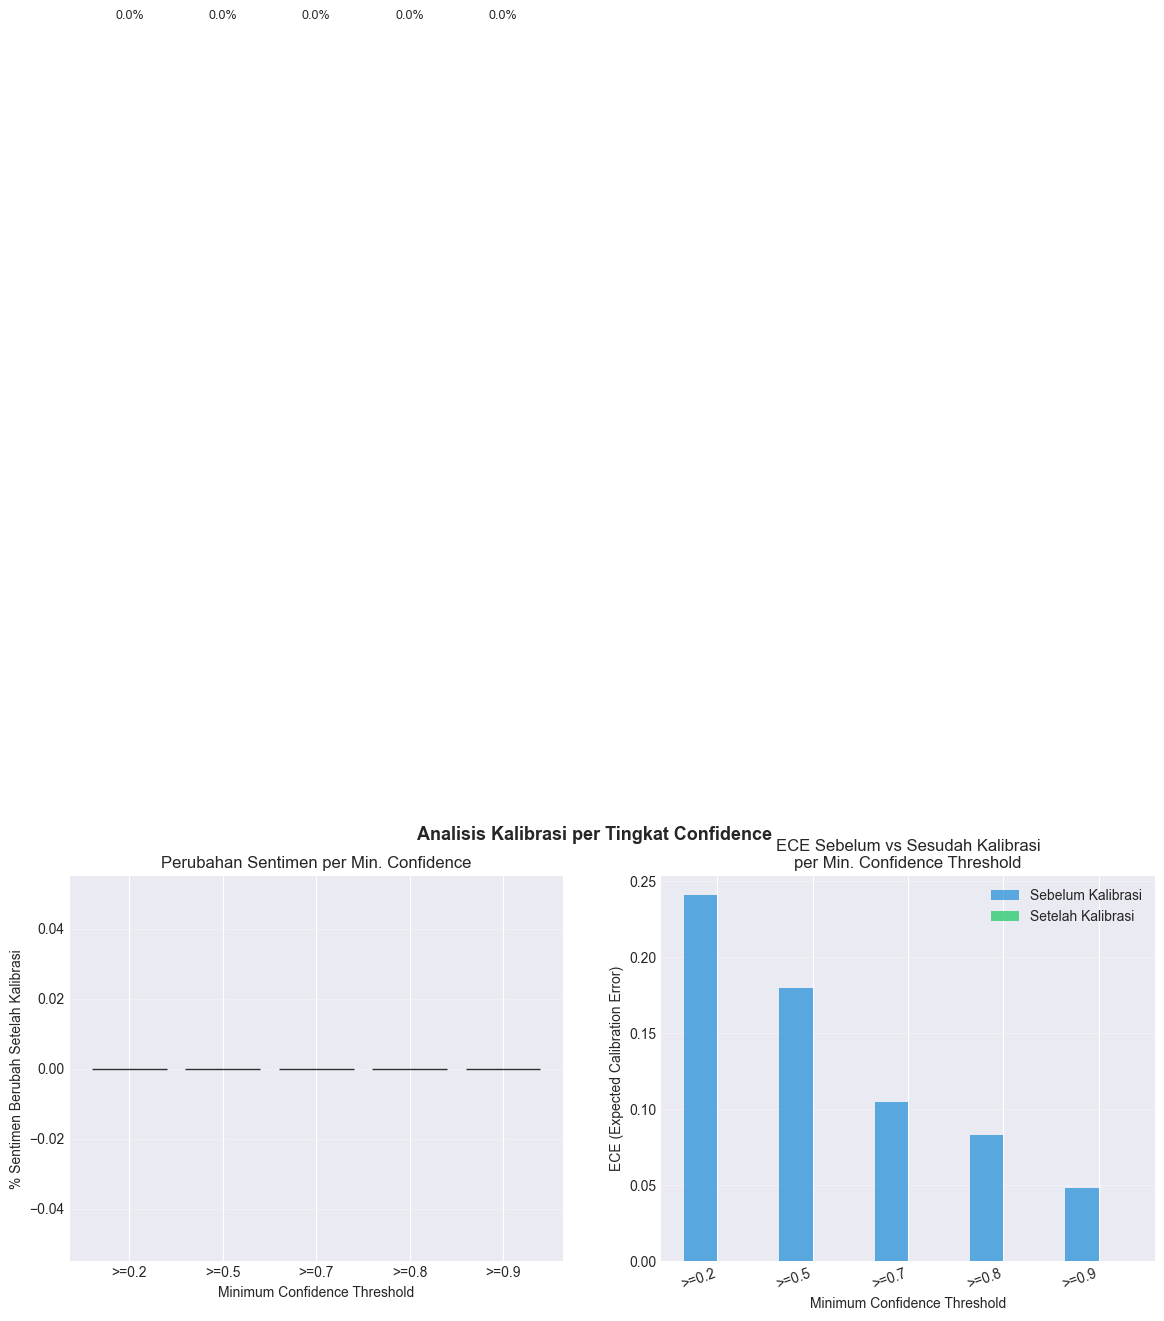

Saved: 01b_calibration_per_confidence.png


In [45]:
# 3b-extra: Dampak Kalibrasi per Tingkat Minimum Confidence
# Untuk setiap threshold confidence, kalibrasi dijalankan pada subset data tersebut
# dan dihitung berapa label sentimen yang berubah setelah kalibrasi.

confidence_thresholds = [0.2, 0.5, 0.7, 0.8, 0.9, 1.0]

print("=== DAMPAK KALIBRASI PER TINGKAT MINIMUM CONFIDENCE ===\n")
print(f"{'Min Conf':>9} | {'N Rows':>10} | {'N Changed':>10} | {'% Changed':>10} | {'ECE Sblm':>9} | {'ECE Sdh':>8}")
print("-" * 72)

cal_conf_rows = []
for min_conf in confidence_thresholds:
    mask = df['sentiment_confidence_level'] >= min_conf
    n = int(mask.sum())

    if n < 20:
        print(f"  >= {min_conf:.1f}   | {n:>10,} | {'-':>10} | {'-':>10} | {'-':>9} | {'terlalu sedikit data':>8}")
        cal_conf_rows.append({
            'min_confidence': min_conf, 'n_rows': n,
            'n_changed': None, 'pct_changed': None,
            'ece_before': None, 'ece_after': None
        })
        continue

    df_sub = df[mask].copy()
    P_sub = df_sub[['p_neg', 'p_neu', 'p_pos']].values.astype(float)
    P_sub = np.clip(P_sub, 1e-12, 1.0)
    P_sub /= P_sub.sum(axis=1, keepdims=True)
    y_sub = _sentiment_to_class_idx(df_sub['final_sentiment'], sent_map)

    ece_before, _, _, _ = compute_ece(y_sub, P_sub)

    # Kalibrasi subset - gunakan 2 fold agar lebih cepat untuk subset besar
    n_folds = max(2, min(5, n // 200))
    try:
        P_sub_cal, sub_metrics = calibrate_cv(
            df_sub, ('p_neg', 'p_neu', 'p_pos'), 'final_sentiment',
            method='isotonic', cv_folds=n_folds
        )
        ece_after = sub_metrics['ece']
    except Exception as e:
        print(f"  Kalibrasi gagal untuk >= {min_conf}: {e}")
        P_sub_cal = P_sub.copy()
        ece_after = ece_before

    _lnorm = {'pro': 'positive', 'contra': 'negative', 'pos': 'positive',
              'neg': 'negative', 'neu': 'neutral'}
    orig_labels = df_sub['final_sentiment'].astype(str).str.lower().values
    orig_labels = np.array([_lnorm.get(l, l) for l in orig_labels])
    cal_label_arr = np.array(['negative', 'neutral', 'positive'])
    cal_labels_sub = cal_label_arr[np.argmax(P_sub_cal, axis=1)]

    n_changed = int((cal_labels_sub != orig_labels).sum())
    pct_changed = 100 * n_changed / n

    print(f"  >= {min_conf:.1f}   | {n:>10,} | {n_changed:>10,} | {pct_changed:>9.2f}% | {ece_before:>9.4f} | {ece_after:>8.4f}")
    cal_conf_rows.append({
        'min_confidence': min_conf, 'n_rows': n,
        'n_changed': n_changed, 'pct_changed': round(pct_changed, 4),
        'ece_before': round(ece_before, 4), 'ece_after': round(ece_after, 4)
    })

print()
df_cal_conf = pd.DataFrame(cal_conf_rows)

# Simpan ke CSV
df_cal_conf.to_csv('ecr_analysis_results/calibration_comparison.csv', index=False)
print("Saved: ecr_analysis_results/calibration_comparison.csv")

# Visualisasi
valid_rows = df_cal_conf.dropna(subset=['pct_changed'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [f">={r}" for r in valid_rows['min_confidence']]
axes[0].bar(x_labels, valid_rows['pct_changed'], color='#e74c3c', alpha=0.8, edgecolor='black')
for j, (_, row) in enumerate(valid_rows.iterrows()):
    axes[0].text(j, row['pct_changed'] + 0.3, f"{row['pct_changed']:.1f}%", ha='center', fontsize=9)
axes[0].set_xlabel('Minimum Confidence Threshold')
axes[0].set_ylabel('% Sentimen Berubah Setelah Kalibrasi')
axes[0].set_title('Perubahan Sentimen per Min. Confidence')
axes[0].grid(True, alpha=0.3, axis='y')

valid_ece = df_cal_conf.dropna(subset=['ece_before', 'ece_after'])
x_ece = np.arange(len(valid_ece))
w = 0.35
axes[1].bar(x_ece - w/2, valid_ece['ece_before'], w, label='Sebelum Kalibrasi', color='#3498db', alpha=0.8)
axes[1].bar(x_ece + w/2, valid_ece['ece_after'],  w, label='Setelah Kalibrasi',  color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x_ece)
axes[1].set_xticklabels([f">={r}" for r in valid_ece['min_confidence']], rotation=20, ha='right')
axes[1].set_xlabel('Minimum Confidence Threshold')
axes[1].set_ylabel('ECE (Expected Calibration Error)')
axes[1].set_title('ECE Sebelum vs Sesudah Kalibrasi\nper Min. Confidence Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Analisis Kalibrasi per Tingkat Confidence', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('01b_calibration_per_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01b_calibration_per_confidence.png")


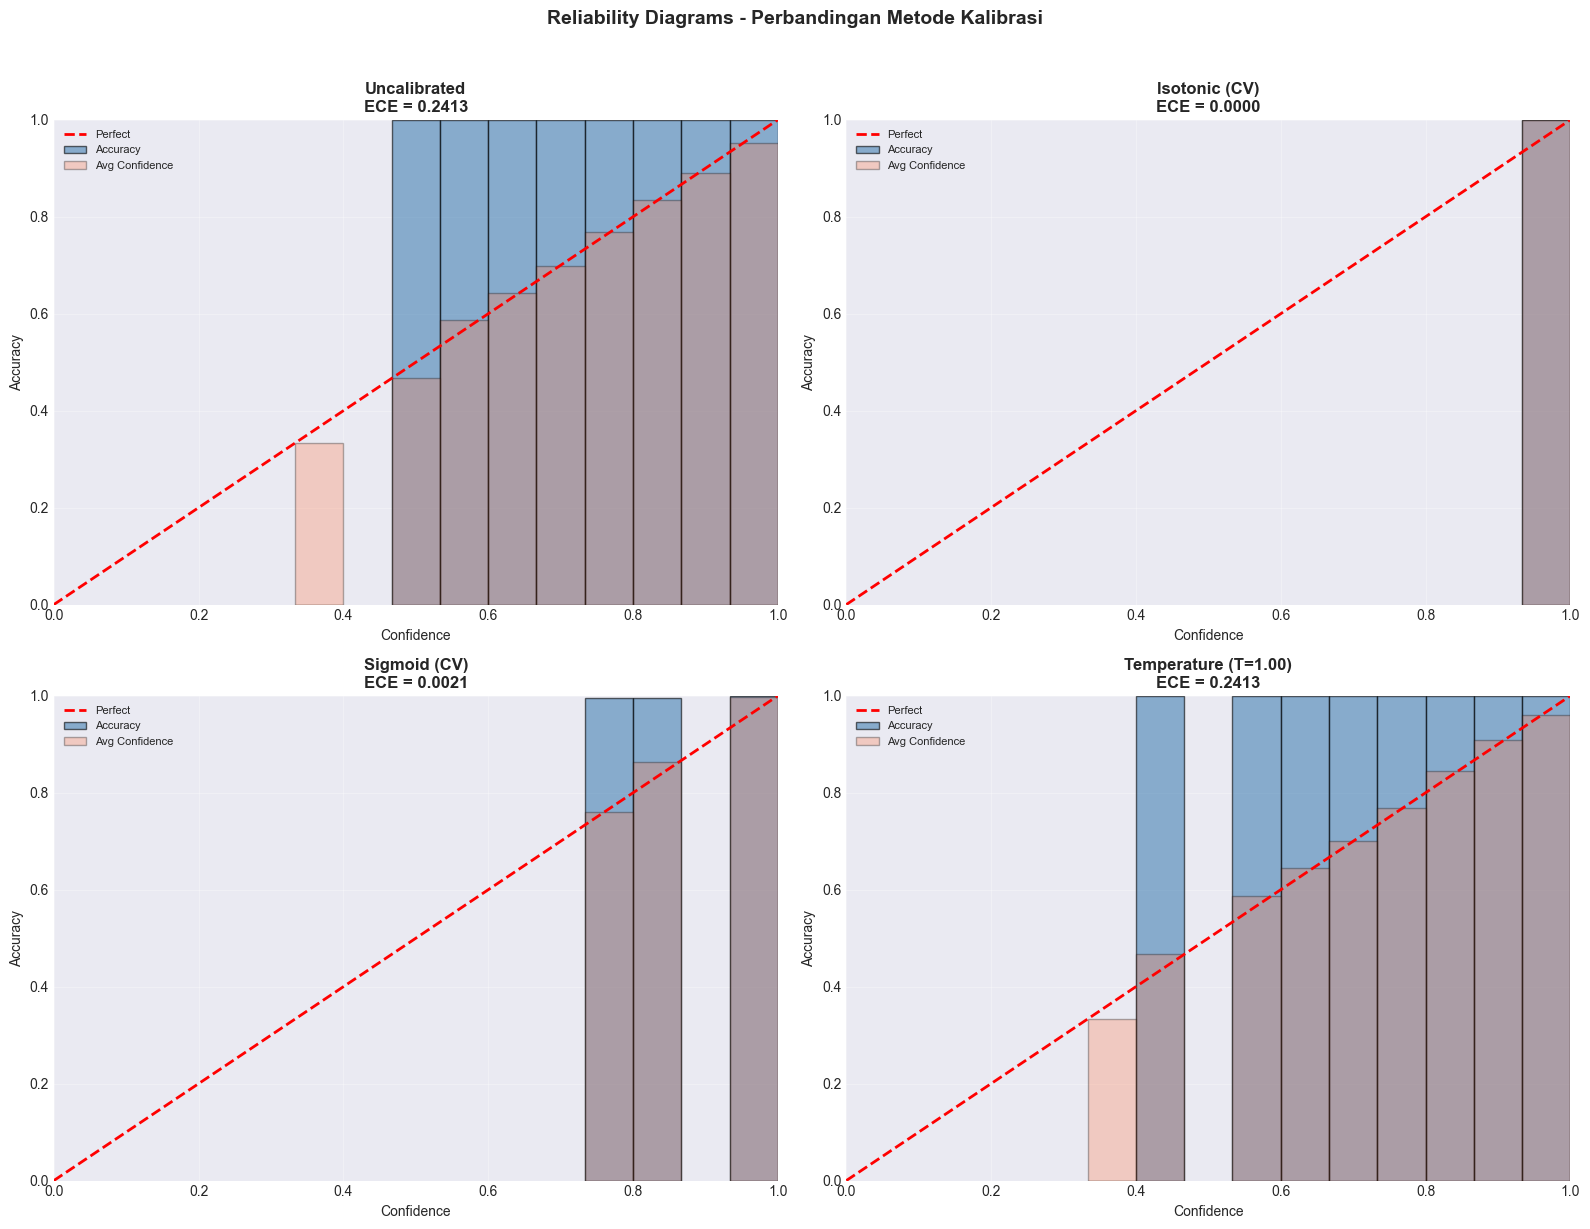

Saved: 01_calibration_impact.png


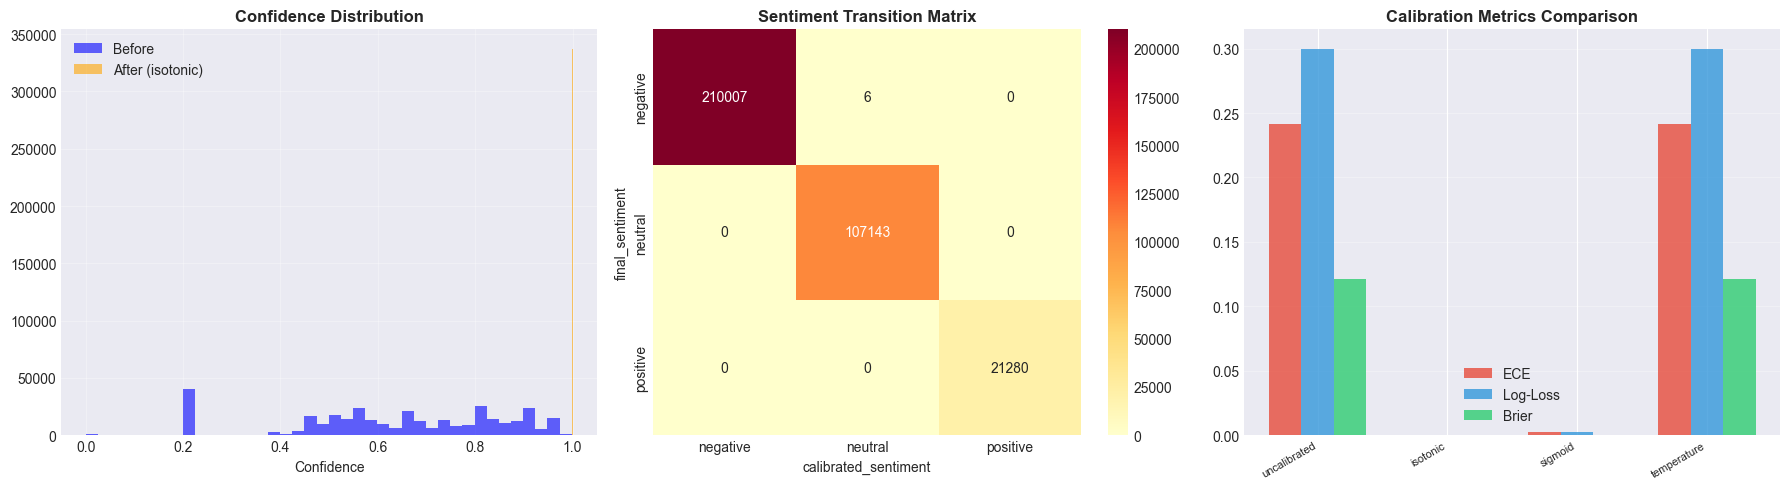

In [46]:
# 3c. Reliability Diagrams (4 panels: uncalibrated + 3 methods)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

all_probs = {
    'Uncalibrated': P_orig,
    'Isotonic (CV)': P_iso,
    'Sigmoid (CV)': P_sig,
    f'Temperature (T={T_opt:.2f})': P_temp,
}

for ax, (title, P_method) in zip(axes.flat, all_probs.items()):
    ece, bin_accs, bin_confs, bin_counts = compute_ece(y_class, P_method)
    n_bins = len(bin_accs)
    bin_centers = (np.arange(n_bins) + 0.5) / n_bins
    mask = bin_counts > 0

    ax.bar(bin_centers[mask], bin_accs[mask], width=1.0/n_bins,
           alpha=0.6, edgecolor='black', color='steelblue', label='Accuracy')
    ax.bar(bin_centers[mask], bin_confs[mask], width=1.0/n_bins,
           alpha=0.3, edgecolor='black', color='coral', label='Avg Confidence')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{title}\nECE = {ece:.4f}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Reliability Diagrams - Perbandingan Metode Kalibrasi', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('01_calibration_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_calibration_impact.png")

# 3d. Additional calibration visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confidence before vs after
axes[0].hist(df['sentiment_confidence_level'], bins=40, alpha=0.6, label='Before', color='blue')
axes[0].hist(df['calibrated_confidence'], bins=40, alpha=0.6, label=f'After ({best_method})', color='orange')
axes[0].set_title('Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Transition matrix
transition = pd.crosstab(df['final_sentiment'], df['calibrated_sentiment'], margins=True)
sns.heatmap(transition.iloc[:-1, :-1], annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Sentiment Transition Matrix', fontweight='bold')

# Calibration comparison bar chart
methods = cal_comparison['method'].values
x_pos = np.arange(len(methods))
width = 0.25
axes[2].bar(x_pos - width, cal_comparison['ece'], width, label='ECE', color='#e74c3c', alpha=0.8)
axes[2].bar(x_pos, cal_comparison['log_loss'], width, label='Log-Loss', color='#3498db', alpha=0.8)
axes[2].bar(x_pos + width, cal_comparison['brier_score'], width, label='Brier', color='#2ecc71', alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(methods, rotation=30, ha='right', fontsize=8)
axes[2].set_title('Calibration Metrics Comparison', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 3.5 Perbandingan Metode Sentiment (10K Sample)

Evaluasi **5 metode sentiment** sebagai pembanding terhadap label IndSight API:
1. **IndoBERT** - pretrained Indonesian BERT (`mdhugol/indonesia-bert-sentiment-classification`), native Indonesian
2. **LLM (Gemini)** - zero-shot classification via Google Generative AI

Ini bersifat **standalone evaluation** - tidak mengubah pipeline utama.
Referensi tetap menggunakan label `final_sentiment` dari IndSight API.

In [47]:
import importlib
import ecr2_pipeline
importlib.reload(ecr2_pipeline)

from ecr2_pipeline import sentiment_indobert


In [48]:
# 3.5a. Sample 10K rows (syarat: TIDAK ADA kolom yang kosong) + IndoBERT

# Tentukan kolom teks
text_col = None
for candidate in ['cleaned_text', 'full_text', 'text', 'content', 'tweet']:
    if candidate in df.columns:
        text_col = candidate
        break

if text_col is None:
    print("WARNING: Kolom teks tidak ditemukan. Melewati perbandingan sentimen.")
else:
    print(f"Kolom teks: '{text_col}'")

    # Filter: tidak ada kolom yang kosong / null
    key_cols = [c for c in [text_col, 'final_sentiment', 'from_id',
                             'sentiment_confidence_level', 'creation_time']
                if c in df.columns]
    df_complete = df.dropna(subset=key_cols)
    # Juga filter baris dengan teks kosong / whitespace
    df_complete = df_complete[df_complete[text_col].str.strip().str.len() > 0]

    print(f"Rows tanpa kolom kosong: {len(df_complete):,} dari {len(df):,} total "
          f"({100*len(df_complete)/len(df):.1f}%)")

    np.random.seed(42)
    sample_size = min(10_000, len(df_complete))
    sample_idx  = np.random.choice(len(df_complete), sample_size, replace=False)
    df_sample   = df_complete.iloc[sample_idx].reset_index(drop=True)
    texts       = df_sample[text_col].values

    print(f"Sample size: {sample_size:,}")
    print(f"Distribusi label di sample:\n{df_sample['final_sentiment'].value_counts().to_dict()}")

    # --- IndoBERT ---
    try:
        df_bert = sentiment_indobert(texts)
        for c in df_bert.columns:
            df_sample[c] = df_bert[c].values
        print(f"\nIndoBERT selesai: {df_bert['indobert_label'].value_counts().to_dict()}")
    except Exception as e:
        print(f"IndoBERT gagal: {e}")


Kolom teks: 'cleaned_text'
Rows tanpa kolom kosong: 338,436 dari 338,436 total (100.0%)
Sample size: 10,000
Distribusi label di sample:
{'negative': 6155, 'neutral': 3218, 'positive': 627}


The following layers were not sharded: bert.encoder.layer.*.intermediate.dense.weight, bert.embeddings.word_embeddings.weight, bert.embeddings.position_embeddings.weight, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.output.LayerNorm.weight, bert.encoder.layer.*.attention.output.dense.weight, bert.pooler.dense.bias, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.output.LayerNorm.bias, classifier.bias, bert.encoder.layer.*.output.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.encoder.layer.*.attention.output.LayerNorm.weight, classifier.weight, bert.encoder.layer.*.output.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.pooler.dense.weight, bert.embeddings.LayerNorm.weight, bert.encoder.layer.*.attention.output.LayerNorm.bias, bert.encoder.layer.*.intermediate.dense.bias, bert.enco

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


IndoBERT selesai: {'negative': 6393, 'neutral': 3361, 'positive': 246}


In [49]:
print("Cell 3.5b (GPT-5.4 robust) mulai dijalankan...")

# LOAD ENV
import os
import pathlib

def _clean_env_value(v: str) -> str:
    return v.strip().strip('"').strip("'")

def load_env():
    for p in [".env", "Leiden/.env"]:
        p = pathlib.Path(p)
        if p.exists():
            with open(p, encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#") or "=" not in line:
                        continue
                    k, v = line.split("=", 1)
                    os.environ[k.strip()] = _clean_env_value(v)
            print("ENV loaded:", p)
            return
    print("WARNING: .env tidak ditemukan")

load_env()

# IMPORT
import ast
import json
import math
import random
import re
import socket
import time
from typing import Any, Iterable, List
from urllib.parse import urlparse

import pandas as pd
import requests

from requests.adapters import HTTPAdapter
from requests.exceptions import (
    ConnectionError,
    ReadTimeout,
    ConnectTimeout,
    SSLError,
    ChunkedEncodingError,
    RequestException,
)
from urllib3.util.retry import Retry

# CONFIG
# Dibuat lebih konservatif agar koneksi lebih stabil
BATCH_SIZE = int(os.environ.get("GPT_BATCH_SIZE", 8))
MAX_CHARS = int(os.environ.get("GPT_MAX_CHARS", 350))
INTER_BATCH_SLEEP = float(os.environ.get("GPT_INTER_BATCH_SLEEP", 1.5))

CONNECT_TIMEOUT = int(os.environ.get("GPT_CONNECT_TIMEOUT", 20))
READ_TIMEOUT = int(os.environ.get("GPT_READ_TIMEOUT", 90))

MAX_BATCH_ATTEMPTS = int(os.environ.get("GPT_MAX_BATCH_ATTEMPTS", 6))
MAX_HTTP_RETRIES = int(os.environ.get("GPT_MAX_HTTP_RETRIES", 3))

CHECKPOINT_FILE = os.environ.get("GPT_CHECKPOINT_FILE", "checkpoint_gpt54_sentiment.csv")
CHECKPOINT_EVERY = int(os.environ.get("GPT_CHECKPOINT_EVERY", 5))

# Secara default proxy dimatikan karena sering menyebabkan ConnectionResetError(10054)
# Kalau memang HARUS pakai proxy, set USE_ENV_PROXY=1 di .env
USE_ENV_PROXY = os.environ.get("USE_ENV_PROXY", "0").strip() == "1"

# SSL verify tetap ON default
VERIFY_SSL = os.environ.get("VERIFY_SSL", "1").strip() == "1"

# Provider priority: OpenAI -> OpenRouter
OPENAI_API_KEY = (os.environ.get("OPENAI_API_KEY") or "").strip()
OPENROUTER_API_KEY = (os.environ.get("OPENROUTER_API_KEY") or "").strip()

if OPENAI_API_KEY:
    PROVIDER = "openai"
    BASE_URL = (os.environ.get("OPENAI_BASE_URL") or "https://api.openai.com/v1").strip()
    API_KEY = OPENAI_API_KEY
    MODEL = (os.environ.get("OPENAI_MODEL") or "gpt-5.4-mini").strip()
elif OPENROUTER_API_KEY:
    PROVIDER = "openrouter"
    BASE_URL = (os.environ.get("OPENROUTER_BASE_URL") or "https://openrouter.ai/api/v1").strip()
    API_KEY = OPENROUTER_API_KEY
    MODEL = (os.environ.get("OPENROUTER_MODEL") or "openai/gpt-5.4-mini").strip()
else:
    raise Exception("API key tidak ditemukan. Isi OPENAI_API_KEY (disarankan) atau OPENROUTER_API_KEY di .env")

CHAT_COMPLETIONS_URL = BASE_URL.rstrip("/") + "/chat/completions"

OUTPUT_COL = os.environ.get("GPT_OUTPUT_COL", "gpt_label")

LABEL_MAP = {
    "positive": "positive",
    "positif": "positive",
    "neutral": "neutral",
    "netral": "neutral",
    "negative": "negative",
    "negatif": "negative",
}

print(f"Provider: {PROVIDER}")
print(f"Base URL: {BASE_URL}")
print(f"Model: {MODEL}")
print(f"Use env proxy: {USE_ENV_PROXY}")
print(f"Verify SSL: {VERIFY_SSL}")
print("Robust mode: ON")

def _preflight_host(url: str):
    host = urlparse(url).hostname
    if not host:
        print("WARNING: BASE_URL tidak valid")
        return
    try:
        socket.gethostbyname(host)
        print(f"Host resolve OK: {host}")
    except Exception as e:
        print(f"WARNING: DNS resolve gagal untuk {host}: {e}")

_preflight_host(BASE_URL)

# PARSER
def _normalize_label(x: Any) -> str:
    key = str(x).strip().lower()
    return LABEL_MAP.get(key, "neutral")

def _pull_labels_from_obj(obj: Any) -> List[str]:
    if isinstance(obj, list):
        out = []
        for item in obj:
            if isinstance(item, str):
                out.append(_normalize_label(item))
            elif isinstance(item, dict):
                cand = (
                    item.get("label")
                    or item.get("sentiment")
                    or item.get("class")
                    or item.get("value")
                )
                if cand is not None:
                    out.append(_normalize_label(cand))
        return out

    if isinstance(obj, dict):
        for key in ["labels", "sentiments", "predictions", "result", "results", "data"]:
            if key in obj:
                nested = _pull_labels_from_obj(obj[key])
                if nested:
                    return nested
    return []

def _extract_json_candidate_blocks(raw: str) -> Iterable[str]:
    txt = raw.strip()
    if txt:
        yield txt

    for m in re.finditer(r"```(?:json)?\s*(.*?)\s*```", raw, flags=re.DOTALL | re.IGNORECASE):
        block = m.group(1).strip()
        if block:
            yield block

    for m in re.finditer(r"\[[\s\S]*?\]", raw):
        yield m.group(0).strip()

    for m in re.finditer(r"\{[\s\S]*?\}", raw):
        yield m.group(0).strip()

def _parse_labels_from_raw(raw: str, expected_n: int) -> List[str]:
    parsed_labels: List[str] = []

    for candidate in _extract_json_candidate_blocks(raw):
        try:
            obj = json.loads(candidate)
            parsed_labels = _pull_labels_from_obj(obj)
            if parsed_labels:
                break
        except json.JSONDecodeError:
            try:
                obj = ast.literal_eval(candidate)
                parsed_labels = _pull_labels_from_obj(obj)
                if parsed_labels:
                    break
            except Exception:
                pass

    if not parsed_labels:
        tokens = re.findall(
            r"\b(positive|positif|neutral|netral|negative|negatif)\b",
            raw.lower()
        )
        parsed_labels = [_normalize_label(t) for t in tokens]

    if len(parsed_labels) < expected_n:
        parsed_labels.extend(["neutral"] * (expected_n - len(parsed_labels)))
    elif len(parsed_labels) > expected_n:
        parsed_labels = parsed_labels[:expected_n]

    return parsed_labels

# HTTP SESSION
def _build_session() -> requests.Session:
    s = requests.Session()
    s.trust_env = USE_ENV_PROXY

    retry = Retry(
        total=MAX_HTTP_RETRIES,
        connect=MAX_HTTP_RETRIES,
        read=MAX_HTTP_RETRIES,
        status=MAX_HTTP_RETRIES,
        backoff_factor=1.2,
        allowed_methods=frozenset(["POST"]),
        status_forcelist=[408, 409, 425, 429, 500, 502, 503, 504],
        raise_on_status=False,
        respect_retry_after_header=True,
    )

    adapter = HTTPAdapter(
        max_retries=retry,
        pool_connections=1,
        pool_maxsize=1,
    )
    s.mount("https://", adapter)
    s.mount("http://", adapter)
    return s

def _is_retryable_exception(e: Exception) -> bool:
    msg = str(e).lower()
    retry_tokens = [
        "connection aborted",
        "connection reset",
        "existing connection was forcibly closed",
        "10054",
        "timed out",
        "timeout",
        "temporarily unavailable",
        "remote host",
        "bad gateway",
        "gateway timeout",
        "server disconnected",
        "ssl",
        "chunkedencodingerror",
        "protocolerror",
    ]
    return (
        isinstance(e, (ConnectionError, ReadTimeout, ConnectTimeout, SSLError, ChunkedEncodingError, OSError))
        or any(tok in msg for tok in retry_tokens)
    )

def _sleep_backoff(base_seconds: float, attempt: int):
    wait_s = min(base_seconds * (2 ** attempt), 45)
    wait_s = wait_s + random.uniform(0.3, 1.3)
    time.sleep(wait_s)

# API CALL
def _chat_completion(prompt: str) -> str:
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
        "User-Agent": "ECR2-GPT54-Robust/1.0",
        "Connection": "close",
        "Accept-Encoding": "identity",
    }

    if PROVIDER == "openrouter":
        headers["HTTP-Referer"] = "https://localhost"
        headers["X-Title"] = "ECR2-GPT-5.4-Sentiment-Robust"

    payload = {
        "model": MODEL,
        "messages": [
            {
                "role": "system",
                "content": (
                    "Anda adalah ahli analisis sentimen Bahasa Indonesia dan memahami slang/gaul. "
                    "Tugas Anda hanya mengklasifikasikan cleaned_text menjadi: positive, neutral, atau negative. "
                    "Selalu kembalikan JSON array murni tanpa penjelasan."
                ),
            },
            {"role": "user", "content": prompt},
        ],
        "temperature": 0,
    }

    # GPT-5 family expects max_completion_tokens (not max_tokens)
    if "gpt-5" in MODEL.lower():
        payload["max_completion_tokens"] = 256
    else:
        payload["max_tokens"] = 256

    last_error = None

    for attempt in range(MAX_BATCH_ATTEMPTS):
        try:
            with _build_session() as s:
                r = s.post(
                    CHAT_COMPLETIONS_URL,
                    headers=headers,
                    json=payload,
                    timeout=(CONNECT_TIMEOUT, READ_TIMEOUT),
                    verify=VERIFY_SSL,
                )

            if r.status_code >= 400:
                body = r.text[:1200]

                # error akses/model
                if r.status_code in (401, 403):
                    raise RuntimeError(
                        f"HTTP {r.status_code}: API key tidak valid / tidak punya akses ke model. Detail: {body}"
                    )
                if r.status_code in (404, 400) and "model" in body.lower() and any(tok in body.lower() for tok in ["not found", "does not exist", "invalid model", "unknown model"]):
                    raise RuntimeError(
                        f"HTTP {r.status_code}: model '{MODEL}' tidak ditemukan / tidak didukung endpoint ini. Detail: {body}"
                    )
                if r.status_code == 429:
                    raise RuntimeError(f"HTTP 429: {body}")
                if r.status_code >= 500:
                    raise RuntimeError(f"HTTP {r.status_code}: {body}")

                raise RuntimeError(f"HTTP {r.status_code}: {body}")

            data = r.json()
            choices = data.get("choices") or []
            if not choices:
                raise RuntimeError(f"Respons API tidak memiliki choices. Raw: {str(data)[:500]}")

            msg = choices[0].get("message") or {}
            content = msg.get("content", "")

            if isinstance(content, list):
                parts = []
                for item in content:
                    if isinstance(item, dict):
                        parts.append(str(item.get("text", "")))
                    else:
                        parts.append(str(item))
                content = "\n".join(parts)

            content = str(content).strip()
            if not content:
                raise RuntimeError("Respons content kosong")

            return content

        except Exception as e:
            last_error = e

            # rate limit
            if "429" in str(e):
                print(f"Rate limit / quota. Retry {attempt+1}/{MAX_BATCH_ATTEMPTS}")
                _sleep_backoff(3, attempt)
                continue

            # koneksi / server error
            if _is_retryable_exception(e) or "http 5" in str(e).lower():
                print(f"Network/server retry {attempt+1}/{MAX_BATCH_ATTEMPTS} | {str(e)[:220]}")
                _sleep_backoff(2, attempt)
                continue

            # error lain -> langsung lempar
            raise

    raise RuntimeError(f"Gagal memanggil API setelah retry. Error terakhir: {last_error}")

# CLASSIFICATION
def _make_prompt(texts: List[str]) -> str:
    numbered = "\n".join(
        f"{i+1}. {str(t).replace(chr(10), ' ').replace(chr(13), ' ')[:MAX_CHARS]}"
        for i, t in enumerate(texts)
    )

    prompt = f"""Klasifikasikan setiap cleaned_text di bawah ini ke dalam salah satu label:
- positive
- neutral
- negative

Daftar cleaned_text:
{numbered}

Aturan:
- Jawab urut sesuai nomor.
- Output WAJIB JSON array murni sebanyak jumlah teks.
- Jangan tambahkan penjelasan apa pun.
- Contoh format:
["positive", "neutral", "negative"]
"""
    return prompt

def classify_batch(texts: List[str], depth: int = 0) -> List[str]:
    expected_n = len(texts)
    if expected_n == 0:
        return []

    # Jika 1 item gagal total, fallback neutral
    if expected_n == 1:
        for attempt in range(MAX_BATCH_ATTEMPTS):
            try:
                raw = _chat_completion(_make_prompt(texts))
                labels = _parse_labels_from_raw(raw, expected_n)
                return labels
            except Exception as e:
                if _is_retryable_exception(e) or "429" in str(e):
                    print(f"Single item retry {attempt+1}/{MAX_BATCH_ATTEMPTS} | {str(e)[:180]}")
                    _sleep_backoff(2, attempt)
                    continue
                print(f"WARN single item gagal: {e}")
                break
        return ["neutral"]

    # batch > 1
    for attempt in range(MAX_BATCH_ATTEMPTS):
        try:
            raw = _chat_completion(_make_prompt(texts))
            labels = _parse_labels_from_raw(raw, expected_n)
            return labels

        except Exception as e:
            msg = str(e).lower()

            if any(tok in msg for tok in ["http 401", "http 403", "tidak valid", "tidak punya akses"]):
                raise RuntimeError(str(e))

            if any(tok in msg for tok in ["http 404", "not found", "invalid model", "unknown model"]):
                raise RuntimeError(str(e))

            if _is_retryable_exception(e) or "429" in msg or "http 5" in msg:
                print(f"WARN batch gagal attempt {attempt+1}/{MAX_BATCH_ATTEMPTS} | n={expected_n} | {str(e)[:220]}")
                _sleep_backoff(2, attempt)
                continue

            print(f"WARN batch non-retryable | n={expected_n} | {e}")
            break

    # Jika batch masih gagal, pecah dua
    print(f"Split batch -> {expected_n} item menjadi 2 bagian")
    mid = math.ceil(expected_n / 2)
    left = classify_batch(texts[:mid], depth + 1)
    right = classify_batch(texts[mid:], depth + 1)
    return left + right

# PREP DATA
if "df_sample" not in globals():
    raise Exception("Jalankan cell 3.5a dulu")

if "text_col" not in globals() or text_col not in df_sample.columns:
    if "cleaned_text" in df_sample.columns:
        text_col = "cleaned_text"
        print("text_col tidak ditemukan, fallback ke 'cleaned_text'")
    else:
        raise Exception("Kolom text tidak ditemukan. Pastikan 'text_col' benar atau kolom 'cleaned_text' ada.")

if OUTPUT_COL not in df_sample.columns:
    df_sample[OUTPUT_COL] = None

# resume dari checkpoint jika ada
checkpoint_path = pathlib.Path(CHECKPOINT_FILE)
if checkpoint_path.exists():
    try:
        old_ckpt = pd.read_csv(checkpoint_path)
        if OUTPUT_COL in old_ckpt.columns and len(old_ckpt) == len(df_sample):
            df_sample[OUTPUT_COL] = old_ckpt[OUTPUT_COL]
            print(f"Checkpoint loaded: {CHECKPOINT_FILE}")
    except Exception as e:
        print(f"WARNING: gagal load checkpoint: {e}")

# pilih baris yang belum diproses
todo_mask = df_sample[OUTPUT_COL].isna() | (df_sample[OUTPUT_COL].astype(str).str.strip() == "")
todo_indices = df_sample.index[todo_mask].tolist()

print("\nModel:", MODEL)
print("Total row:", len(df_sample))
print("Belum diproses:", len(todo_indices))
print("Batch size:", BATCH_SIZE)
print("Kolom teks:", text_col)
print("\nMemulai klasifikasi...\n")

processed_batches = 0

for start in range(0, len(todo_indices), BATCH_SIZE):
    idxs = todo_indices[start:start + BATCH_SIZE]
    batch_texts = (
        df_sample.loc[idxs, text_col]
        .fillna("")
        .astype(str)
        .tolist()
    )

    labels = classify_batch(batch_texts)

    if len(labels) != len(idxs):
        # jaga-jaga
        if len(labels) < len(idxs):
            labels = labels + ["neutral"] * (len(idxs) - len(labels))
        else:
            labels = labels[:len(idxs)]

    df_sample.loc[idxs, OUTPUT_COL] = labels

    processed_batches += 1
    done = min(start + BATCH_SIZE, len(todo_indices))
    print(f"{done}/{len(todo_indices)} selesai")

    # checkpoint berkala
    if processed_batches % CHECKPOINT_EVERY == 0 or done == len(todo_indices):
        try:
            df_sample.to_csv(CHECKPOINT_FILE, index=False, encoding="utf-8-sig")
            print(f"Checkpoint saved -> {CHECKPOINT_FILE}")
        except Exception as e:
            print(f"WARNING: gagal simpan checkpoint: {e}")

    time.sleep(INTER_BATCH_SLEEP)

print("\nKlasifikasi selesai.")

# EVALUATION
if "final_sentiment" in df_sample.columns:
    from sklearn.metrics import accuracy_score, f1_score, classification_report

    ref = df_sample["final_sentiment"].fillna("").astype(str).str.lower().map(lambda x: LABEL_MAP.get(x, x))
    pred = df_sample[OUTPUT_COL].fillna("neutral").astype(str).str.lower().map(lambda x: LABEL_MAP.get(x, "neutral"))

    valid_mask = ref.isin(["positive", "neutral", "negative"])
    if valid_mask.sum() > 0:
        ref_valid = ref[valid_mask]
        pred_valid = pred[valid_mask]

        print("\nDistribusi GPT:", pred_valid.value_counts().to_dict())

        acc = accuracy_score(ref_valid, pred_valid)
        f1 = f1_score(ref_valid, pred_valid, average="macro")

        print("Accuracy:", acc)
        print("Macro F1:", f1)
        print("\nClassification report\n")
        print(classification_report(ref_valid, pred_valid))
    else:
        print("Kolom final_sentiment ada, tapi isinya tidak valid untuk evaluasi.")
else:
    print("Kolom final_sentiment tidak ada, evaluasi dilewati.")

print("Cell 3.5b (GPT-5.4 robust) selesai.")

Cell 3.5b (GPT-5.4 robust) mulai dijalankan...
ENV loaded: .env
Provider: openai
Base URL: https://api.openai.com/v1
Model: gpt-5.4-mini
Use env proxy: False
Verify SSL: True
Robust mode: ON
Host resolve OK: api.openai.com

Model: gpt-5.4-mini
Total row: 10000
Belum diproses: 10000
Batch size: 8
Kolom teks: cleaned_text

Memulai klasifikasi...

8/10000 selesai
16/10000 selesai
24/10000 selesai
32/10000 selesai
40/10000 selesai
Checkpoint saved -> checkpoint_gpt54_sentiment.csv
48/10000 selesai
56/10000 selesai
64/10000 selesai
72/10000 selesai
80/10000 selesai
Checkpoint saved -> checkpoint_gpt54_sentiment.csv
88/10000 selesai
96/10000 selesai
104/10000 selesai
112/10000 selesai
120/10000 selesai
Checkpoint saved -> checkpoint_gpt54_sentiment.csv
128/10000 selesai
136/10000 selesai
144/10000 selesai
152/10000 selesai
160/10000 selesai
Checkpoint saved -> checkpoint_gpt54_sentiment.csv
168/10000 selesai
176/10000 selesai
184/10000 selesai
192/10000 selesai
200/10000 selesai
Checkpoint s

KeyboardInterrupt: 

In [50]:
print("Cell 3.5c (Lanjut inferensi dari row 1802)...")

# RELOAD CHECKPOINT & DATA
print("Loading checkpoint dan data...")

# Load data yang sudah diproses
checkpoint_path = pathlib.Path(CHECKPOINT_FILE)
if not checkpoint_path.exists():
    print("ERROR: Checkpoint tidak ditemukan. Jalankan cell berisi batch inference dulu.")
    raise Exception(f"File {CHECKPOINT_FILE} tidak ditemukan")

df_results = pd.read_csv(checkpoint_path)
print(f"Checkpoint loaded: {len(df_results)} rows")

# Verifikasi struktur
if text_col not in df_results.columns:
    raise Exception(f"Kolom '{text_col}' tidak ada di checkpoint")

if OUTPUT_COL not in df_results.columns:
    df_results[OUTPUT_COL] = None
    print(f"Kolom '{OUTPUT_COL}' dibuat")

# Identifikasi baris yang belum diproses
todo_mask = df_results[OUTPUT_COL].isna() | (df_results[OUTPUT_COL].astype(str).str.strip() == "")
todo_indices = df_results.index[todo_mask].tolist()

print(f"\nTotal rows: {len(df_results)}")
print(f"Sudah diproses: {len(df_results) - len(todo_indices)}")
print(f"Belum diproses: {len(todo_indices)}")

if len(todo_indices) == 0:
    print("Semua data sudah diproses!")
else:
    first_todo = todo_indices[0]
    last_todo = todo_indices[-1]
    print(f"Range belum diproses: {first_todo} - {last_todo}")

# LANJUT INFERENSI
if len(todo_indices) > 0:
    print("\nMemulai batch processing untuk baris yang belum diproses...\n")
    
    processed_batches = 0
    
    for start in range(0, len(todo_indices), BATCH_SIZE):
        idxs = todo_indices[start:start + BATCH_SIZE]
        batch_texts = (
            df_results.loc[idxs, text_col]
            .fillna("")
            .astype(str)
            .tolist()
        )
        
        try:
            labels = classify_batch(batch_texts)
            
            if len(labels) != len(idxs):
                if len(labels) < len(idxs):
                    labels = labels + ["neutral"] * (len(idxs) - len(labels))
                else:
                    labels = labels[:len(idxs)]
            
            df_results.loc[idxs, OUTPUT_COL] = labels
            
            processed_batches += 1
            done = min(start + BATCH_SIZE, len(todo_indices))
            progress_pct = f"{100*done/len(todo_indices):.1f}%"
            print(f"[{progress_pct}] {done}/{len(todo_indices)} selesai (baris {idxs[0]}-{idxs[-1]})")
            
            # Checkpoint berkala
            if processed_batches % CHECKPOINT_EVERY == 0 or done == len(todo_indices):
                try:
                    df_results.to_csv(CHECKPOINT_FILE, index=False, encoding="utf-8-sig")
                    print(f"  → Checkpoint saved")
                except Exception as e:
                    print(f"  WARNING: gagal simpan checkpoint: {e}")
            
            time.sleep(INTER_BATCH_SLEEP)
        
        except Exception as e:
            print(f"ERROR di batch {start}-{start+len(idxs)}: {e}")
            print(f"Tetap menyimpan checkpoint sebelum melanjutkan")
            try:
                df_results.to_csv(CHECKPOINT_FILE, index=False, encoding="utf-8-sig")
            except:
                pass
            raise
    
    print("\n✓ Batch processing selesai!")
    
    # EVALUATION
    if "final_sentiment" in df_results.columns:
        from sklearn.metrics import accuracy_score, f1_score, classification_report
        
        ref = df_results["final_sentiment"].fillna("").astype(str).str.lower().map(lambda x: LABEL_MAP.get(x, x))
        pred = df_results[OUTPUT_COL].fillna("neutral").astype(str).str.lower().map(lambda x: LABEL_MAP.get(x, "neutral"))
        
        valid_mask = ref.isin(["positive", "neutral", "negative"])
        if valid_mask.sum() > 0:
            ref_valid = ref[valid_mask]
            pred_valid = pred[valid_mask]
            
            print("\nEVALUASI HASIL:")
            print("Distribusi GPT:", pred_valid.value_counts().to_dict())
            
            acc = accuracy_score(ref_valid, pred_valid)
            f1 = f1_score(ref_valid, pred_valid, average="macro")
            
            print(f"Accuracy: {acc:.4f}")
            print(f"Macro F1: {f1:.4f}")
            print("\nClassification report:\n")
            print(classification_report(ref_valid, pred_valid))
        else:
            print("Kolom final_sentiment ada, tapi isinya tidak valid untuk evaluasi")
    else:
        print("Kolom final_sentiment tidak ada, evaluasi dilewati")
    
    # Save final hasil
    try:
        df_results.to_csv(CHECKPOINT_FILE, index=False, encoding="utf-8-sig")
        print(f"\n✓ Final hasil disimpan ke {CHECKPOINT_FILE}")
    except Exception as e:
        print(f"WARNING: gagal simpan final: {e}")
        
else:
    print("\n✓ Tidak ada baris yang perlu diproses")

print("\nCell 3.5c selesai.")

Cell 3.5c (Lanjut inferensi dari row 1802)...
Loading checkpoint dan data...
Checkpoint loaded: 10000 rows

Total rows: 10000
Sudah diproses: 1800
Belum diproses: 8200
Range belum diproses: 1800 - 9999

Memulai batch processing untuk baris yang belum diproses...

[0.1%] 8/8200 selesai (baris 1800-1807)
[0.2%] 16/8200 selesai (baris 1808-1815)
[0.3%] 24/8200 selesai (baris 1816-1823)
[0.4%] 32/8200 selesai (baris 1824-1831)
[0.5%] 40/8200 selesai (baris 1832-1839)
  → Checkpoint saved
[0.6%] 48/8200 selesai (baris 1840-1847)
[0.7%] 56/8200 selesai (baris 1848-1855)
[0.8%] 64/8200 selesai (baris 1856-1863)
[0.9%] 72/8200 selesai (baris 1864-1871)
[1.0%] 80/8200 selesai (baris 1872-1879)
  → Checkpoint saved
[1.1%] 88/8200 selesai (baris 1880-1887)
[1.2%] 96/8200 selesai (baris 1888-1895)
[1.3%] 104/8200 selesai (baris 1896-1903)
[1.4%] 112/8200 selesai (baris 1904-1911)
[1.5%] 120/8200 selesai (baris 1912-1919)
  → Checkpoint saved
[1.6%] 128/8200 selesai (baris 1920-1927)
[1.7%] 136/820

=== PERBANDINGAN METODE SENTIMENT ===
            Method  N Valid  Accuracy  Macro-F1   F1 Neg   F1 Neu   F1 Pos  Precision   Recall
          IndoBERT    10000     0.583  0.411235 0.707523 0.407053 0.119129   0.434710 0.406745
LLM (GPT 5.4 mini)    10000     0.376  0.296341 0.238665 0.476660 0.173697   0.471073 0.375597


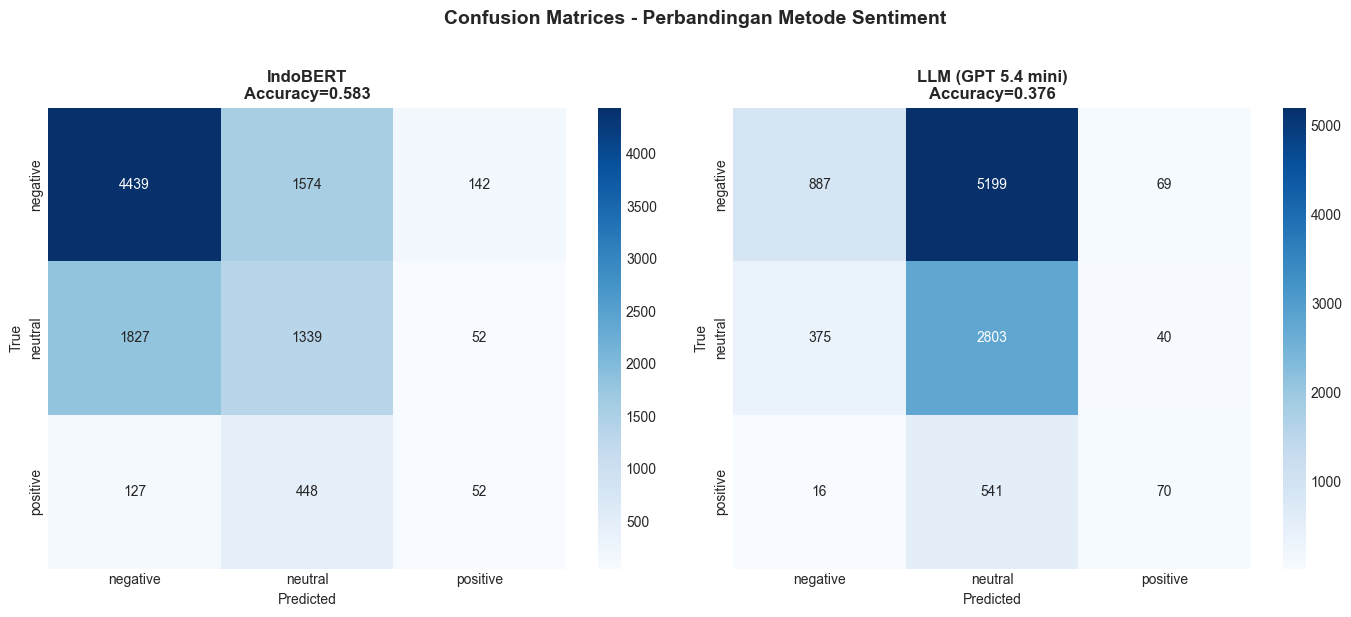

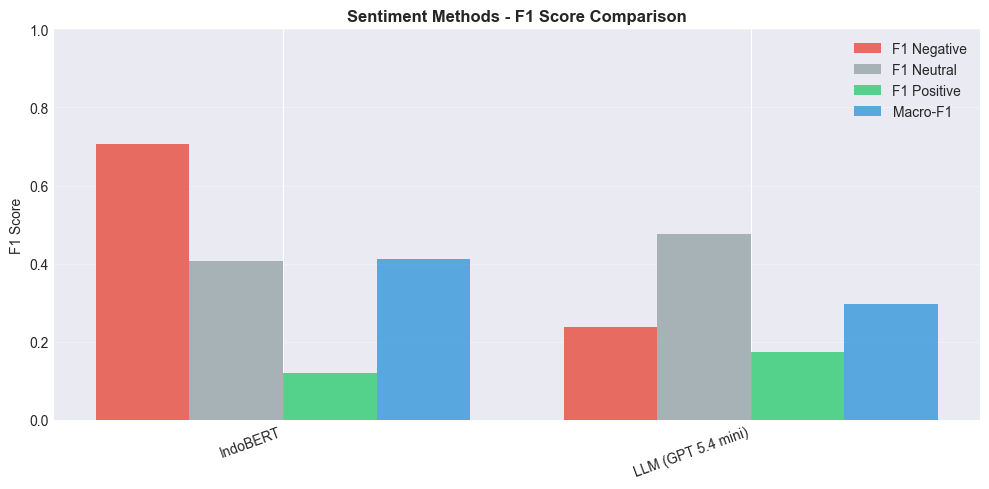

In [52]:
# # Tentukan kolom teks
# text_col = None
# for candidate in ['cleaned_text', 'full_text', 'text', 'content', 'tweet']:
#     if candidate in df.columns:
#         text_col = candidate
#         break

# 3.5c. Evaluasi semua metode sentimen + Confusion matrices + F1 bar chart

if text_col is not None:
    _label_norm = {'pro': 'positive', 'pos': 'positive',
                   'contra': 'negative', 'neg': 'negative', 'neu': 'neutral',
                   'positif': 'positive', 'negatif': 'negative', 'netral': 'neutral'}
    labels_order = ['negative', 'neutral', 'positive']

    def _normalize_labels(series):
        return (series
                .fillna('neutral')
                .astype(str)
                .str.strip()
                .str.lower()
                .map(lambda x: _label_norm.get(x, x)))

    ref = _normalize_labels(df_sample['final_sentiment'])

    method_cols = {
        'IndoBERT': 'indobert_label',
        'LLM (GPT 5.4 mini)': 'gpt_label',
    }
    predictions = {name: df_sample[col]
                   for name, col in method_cols.items() if col in df_sample.columns}

    missing_methods = [name for name, col in method_cols.items()
                       if col not in df_sample.columns]
    if missing_methods:
        print(f"Metode tidak tersedia (dilewati): {missing_methods}")

    if len(predictions) == 0:
        print("Tidak ada kolom prediksi sentimen. Evaluasi dilewati.")
    else:
        from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                                     recall_score, confusion_matrix)

        eval_rows = []
        conf_matrices = {}
        predictions_norm = {}

        for name, preds in predictions.items():
            pred = _normalize_labels(preds)

            # Hanya evaluasi label valid agar tidak ada campuran tipe / nilai liar
            valid_mask = ref.isin(labels_order) & pred.isin(labels_order)
            n_valid = int(valid_mask.sum())

            if n_valid == 0:
                print(f"{name}: tidak ada label valid untuk evaluasi, dilewati.")
                continue

            ref_v = ref[valid_mask].astype(str)
            pred_v = pred[valid_mask].astype(str)

            acc = accuracy_score(ref_v, pred_v)
            f1_mac = f1_score(ref_v, pred_v, labels=labels_order, average='macro', zero_division=0)
            f1_per = f1_score(ref_v, pred_v, labels=labels_order, average=None, zero_division=0)
            prec = precision_score(ref_v, pred_v, labels=labels_order, average='macro', zero_division=0)
            rec = recall_score(ref_v, pred_v, labels=labels_order, average='macro', zero_division=0)
            cm = confusion_matrix(ref_v, pred_v, labels=labels_order)

            eval_rows.append({
                'Method': name, 'N Valid': n_valid,
                'Accuracy': acc, 'Macro-F1': f1_mac,
                'F1 Neg': f1_per[0], 'F1 Neu': f1_per[1], 'F1 Pos': f1_per[2],
                'Precision': prec, 'Recall': rec
            })
            conf_matrices[name] = cm
            predictions_norm[name] = pred_v

        if len(eval_rows) == 0:
            print("Semua metode dilewati karena tidak ada label valid.")
        else:
            df_eval = pd.DataFrame(eval_rows)
            print("=== PERBANDINGAN METODE SENTIMENT ===")
            print(df_eval.to_string(index=False))

            # Confusion matrices
            n_methods = len(conf_matrices)
            ncols = min(3, n_methods)
            nrows = math.ceil(n_methods / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
            if n_methods == 1:
                axes = np.array([axes])

            for ax, (name, cm) in zip(np.array(axes).flat, conf_matrices.items()):
                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                            xticklabels=labels_order, yticklabels=labels_order)
                acc_v = accuracy_score(ref[ref.isin(labels_order) & _normalize_labels(predictions[name]).isin(labels_order)].astype(str),
                                       _normalize_labels(predictions[name])[ref.isin(labels_order) & _normalize_labels(predictions[name]).isin(labels_order)].astype(str))
                ax.set_title(f'{name}\nAccuracy={acc_v:.3f}', fontweight='bold')
                ax.set_xlabel('Predicted')
                ax.set_ylabel('True')

            for ax in list(np.array(axes).flat)[len(conf_matrices):]:
                ax.axis('off')

            plt.suptitle('Confusion Matrices - Perbandingan Metode Sentiment',
                         fontweight='bold', fontsize=14, y=1.02)
            plt.tight_layout()
            plt.show()

            # F1 bar chart
            fig, ax = plt.subplots(figsize=(max(10, 4 * len(df_eval)), 5))
            x = np.arange(len(df_eval))
            width = 0.2
            ax.bar(x - 1.5 * width, df_eval['F1 Neg'], width, label='F1 Negative', color='#e74c3c', alpha=0.8)
            ax.bar(x - 0.5 * width, df_eval['F1 Neu'], width, label='F1 Neutral', color='#95a5a6', alpha=0.8)
            ax.bar(x + 0.5 * width, df_eval['F1 Pos'], width, label='F1 Positive', color='#2ecc71', alpha=0.8)
            ax.bar(x + 1.5 * width, df_eval['Macro-F1'], width, label='Macro-F1', color='#3498db', alpha=0.8)
            ax.set_xticks(x)
            ax.set_xticklabels(df_eval['Method'], rotation=20, ha='right')
            ax.set_ylabel('F1 Score')
            ax.set_title('Sentiment Methods - F1 Score Comparison', fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim(0, 1)
            plt.tight_layout()
            plt.show()
else:
    print("Evaluasi sentimen dilewati (kolom teks tidak ditemukan).")


---
## 4. Build Interaction Graph
1. **Mention parsing**  --  bersihkan karakter sampah (tanda kurung, spasi, non-alphanumeric trailing chars)
2. **Filter edges**  --  hanya simpan edges di mana **kedua** user punya data content/leaning
3. Ini memastikan tidak ada node "ghost" yang menyebabkan NaN

In [53]:
# 4a. Build graph function

def build_graph(
    interactions: pd.DataFrame,
    directed: bool = True,
) -> Tuple:
    G = nx.DiGraph() if directed else nx.Graph()
    
    for _, row in tqdm(interactions.iterrows(), total=len(interactions), desc="Building graph", leave=False):
        s, d = str(row["src"]).strip(), str(row["dst"]).strip()
        w = float(row.get("weight", 1.0))
        t = row.get("type", "edge")
        if G.has_edge(s, d):
            G[s][d]["weight"] += w
        else:
            G.add_edge(s, d, weight=w, itype=t)
    
    df_nodes = pd.DataFrame({"user": list(G.nodes())})
    return G, df_nodes

In [54]:
# 4b. Prepare interactions -- proper mention parsing
content_users = set(df['from_id'].dropna().unique())
print(f"Users with content: {len(content_users):,}")
interactions_list = []

# Reply
if 'reply_to_user_id' in df.columns:
    r = df.loc[df['reply_to_user_id'].notna(), ['from_id','reply_to_user_id']].copy()
    r.columns = ['src','dst']; r = r.dropna(); r['type']='reply'; r['weight']=1
    interactions_list.append(r); print(f"Reply: {len(r):,}")

# Retweet
rt_col = 'retweet_from_user_id'
if rt_col in df.columns:
    r = df.loc[df[rt_col].notna(), ['from_id', rt_col]].copy()
    r.columns = ['src','dst']; r = r.dropna(); r['type']='retweet'; r['weight']=1
    interactions_list.append(r); print(f"Retweet: {len(r):,}")

# Mention, parse (name,XXX)//(id,YYY) format
if 'mentioned' in df.columns:
    md = []
    for _, row in df[df['mentioned'].notna()].iterrows():
        for item in parse_mentioned(row['mentioned']):
            if item['user_id'] and item['user_id'] != row['from_id']:
                md.append({'src': row['from_id'], 'dst': item['user_id'],
                           'type': 'mention', 'weight': 1})
    if md:
        interactions_list.append(pd.DataFrame(md)); print(f"Mention: {len(md):,}")

interactions = pd.concat(interactions_list, ignore_index=True)
interactions = interactions[interactions['src'] != interactions['dst']]
before = len(interactions)
interactions = interactions[interactions['src'].isin(content_users) & interactions['dst'].isin(content_users)]
print(f"\nFiltered: {before:,} -> {len(interactions):,}")
print(f"\n{interactions['type'].value_counts()}")

Users with content: 116,675
Reply: 29,906
Retweet: 277,726
Mention: 53,378

Filtered: 357,480 -> 260,651

type
retweet    220876
mention     24379
reply       15396
Name: count, dtype: int64


In [55]:
# 4c. Build the graph

G, df_nodes = build_graph(interactions, directed=True)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

print(f"\nGraph Statistics:")
print(f"Nodes: {n_nodes:,}")
print(f"Edges: {n_edges:,}")
print(f"Density: {density:.6f}")
print(f"Avg degree: {2*n_edges/n_nodes:.2f}")

# Verifikasi: semua node punya content data
nodes_without_content = set(G.nodes()) - content_users
print(f"\nNodes without content: {len(nodes_without_content)} (harus 0)")


Graph Statistics:
Nodes: 91,784
Edges: 194,491
Density: 0.000023
Avg degree: 4.24

Nodes without content: 0 (harus 0)


---
## 5. Estimasi User Leaning

Menghitung kecenderungan setiap user dalam skala [-1, +1] menggunakan probabilitas **terkalibrasi**.

**Mapping Pro/Kontra untuk topik "Indonesia Gelap":**
- **Sentimen NEGATIF** = **PRO** topik (setuju Indonesia Gelap) -> lean_scalar positif (+1)
- **Sentimen POSITIF** = **KONTRA** topik (tidak setuju Indonesia Gelap) -> lean_scalar negatif (-1)
- **Sentimen NETRAL** = Netral -> lean_scalar sekitar 0

Parameter `topic_polarity="negative_is_pro"` mengontrol mapping ini.
Untuk topik lain dimana sentimen positif = PRO, gunakan `"positive_is_pro"`.

In [56]:
def estimate_user_leaning(
    content: pd.DataFrame,
    user_col: str = "user",
    proba_cols: Tuple[str, ...] = ("p_neg", "p_neu", "p_pos"),
    topic_polarity: str = "negative_is_pro",
) -> pd.DataFrame:
    """Estimate per-user scalar leaning in [-1, +1].

    topic_polarity:
        'negative_is_pro': sentimen negatif = PRO topik -> lean = +1*p_neg + 0*p_neu + -1*p_pos
        'positive_is_pro': sentimen positif = PRO topik -> lean = -1*p_neg + 0*p_neu + +1*p_pos
    """
    df_c = content.copy()

    p_neg, p_neu, p_pos = [df_c[c].astype(float).values for c in proba_cols]
    eps = 1e-12
    s = p_neg + p_neu + p_pos + eps
    p_neg, p_neu, p_pos = p_neg/s, p_neu/s, p_pos/s

    if topic_polarity == "negative_is_pro":
        df_c["lean_scalar"] = 1.0 * p_neg + 0.0 * p_neu + (-1.0) * p_pos
    else:
        df_c["lean_scalar"] = (-1.0) * p_neg + 0.0 * p_neu + 1.0 * p_pos

    P = np.vstack([p_neg, p_neu, p_pos]).T
    ent = -np.sum(np.where(P > 0, P * np.log(P + 1e-12), 0.0), axis=1)
    ent_max = math.log(3.0)
    df_c["conf"] = 1.0 - (ent / ent_max)
    df_c["_p_neg"] = p_neg
    df_c["_p_neu"] = p_neu
    df_c["_p_pos"] = p_pos

    agg = df_c.groupby(user_col).agg(
        lean_scalar=("lean_scalar", "mean"),
        conf=("conf", "mean"),
        p_neg_mean=("_p_neg", "mean"),
        p_neu_mean=("_p_neu", "mean"),
        p_pos_mean=("_p_pos", "mean"),
    ).reset_index()
    agg.rename(columns={user_col: "user"}, inplace=True)
    agg["lean_scalar"] = agg["lean_scalar"].clip(-1.0, 1.0)
    agg["conf"] = agg["conf"].clip(0.0, 1.0)

    return agg

# Buat content table dengan probabilitas TERKALIBRASI
content = df[['from_id', 'p_neg_cal', 'p_neu_cal', 'p_pos_cal']].copy()
content.columns = ['user', 'p_neg', 'p_neu', 'p_pos']

df_users = estimate_user_leaning(content, user_col='user',
                                  proba_cols=('p_neg', 'p_neu', 'p_pos'),
                                  topic_polarity='negative_is_pro')

print(f"Users with leaning (from content): {len(df_users):,}")
print(f"Columns: {list(df_users.columns)}")

# Propagate leaning ke node graf yang TIDAK punya content
graph_nodes = set(G.nodes())
users_with_lean = set(df_users['user'].values)
nodes_without_lean = graph_nodes - users_with_lean

print(f"Graph nodes without content: {len(nodes_without_lean):,}")

if len(nodes_without_lean) > 0:
    lean_dict = dict(zip(df_users['user'], df_users['lean_scalar']))
    conf_dict = dict(zip(df_users['user'], df_users['conf']))
    pn_dict = dict(zip(df_users['user'], df_users['p_neg_mean']))
    pneu_dict = dict(zip(df_users['user'], df_users['p_neu_mean']))
    pp_dict = dict(zip(df_users['user'], df_users['p_pos_mean']))

    propagated = []
    for node in nodes_without_lean:
        nbrs = list(G.predecessors(node)) + list(G.successors(node)) if isinstance(G, nx.DiGraph) else list(G.neighbors(node))
        neighbor_leans = [lean_dict[n] for n in nbrs if n in lean_dict]

        if neighbor_leans:
            propagated.append({
                'user': node,
                'lean_scalar': float(np.mean(neighbor_leans)),
                'conf': 0.5,
                'p_neg_mean': float(np.mean([pn_dict.get(n, 0.33) for n in nbrs if n in pn_dict])),
                'p_neu_mean': float(np.mean([pneu_dict.get(n, 0.33) for n in nbrs if n in pneu_dict])),
                'p_pos_mean': float(np.mean([pp_dict.get(n, 0.33) for n in nbrs if n in pp_dict])),
            })

    if propagated:
        df_propagated = pd.DataFrame(propagated)
        df_users = pd.concat([df_users, df_propagated], ignore_index=True)
        print(f"Propagated leaning to {len(propagated):,} nodes from neighbors")

print(f"\nTotal users with leaning: {len(df_users):,}")
print(f"\nLeaning statistics:")
print(df_users[['lean_scalar', 'conf']].describe())

# Verifikasi coverage
users_with_lean = set(df_users['user'].values)
coverage = len(graph_nodes & users_with_lean)
print(f"\n[OK] Graph nodes with leaning: {coverage:,} / {len(graph_nodes):,} ({100*coverage/len(graph_nodes):.1f}%)")

# Validasi: assert 1:1 user mapping
assert df_users['user'].duplicated().sum() == 0, "DUPLICATE users detected!"
print("[OK] 1:1 user mapping verified (no duplicates)")

Users with leaning (from content): 116,675
Columns: ['user', 'lean_scalar', 'conf', 'p_neg_mean', 'p_neu_mean', 'p_pos_mean']
Graph nodes without content: 0

Total users with leaning: 116,675

Leaning statistics:
         lean_scalar           conf
count  116675.000000  116675.000000
mean        0.589707       0.999915
std         0.543604       0.001304
min        -1.000000       0.969601
25%         0.142857       1.000000
50%         1.000000       1.000000
75%         1.000000       1.000000
max         1.000000       1.000000

[OK] Graph nodes with leaning: 91,784 / 91,784 (100.0%)
[OK] 1:1 user mapping verified (no duplicates)


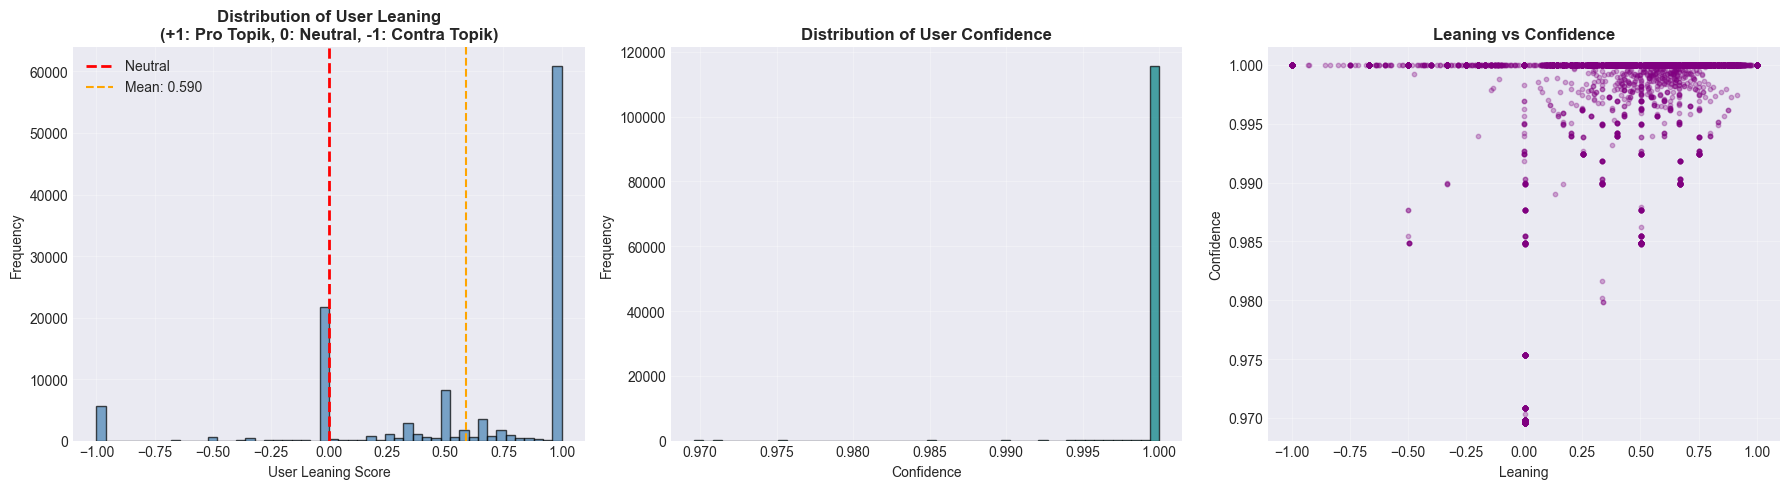

In [57]:
# Visualisasi user leaning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_users['lean_scalar'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0].axvline(x=df_users['lean_scalar'].mean(), color='orange', linestyle='--',
                label=f'Mean: {df_users["lean_scalar"].mean():.3f}')
axes[0].set_xlabel('User Leaning Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of User Leaning\n(+1: Pro Topik, 0: Neutral, -1: Contra Topik)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_users['conf'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of User Confidence', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df_users['lean_scalar'], df_users['conf'], alpha=0.3, s=10, c='purple')
axes[2].set_xlabel('Leaning')
axes[2].set_ylabel('Confidence')
axes[2].set_title('Leaning vs Confidence', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_user_leaning.png', dpi=150, bbox_inches='tight')
plt.show()

=== USER STATS DIAGNOSTICS ===

Distribusi jumlah posts per user:
count    116675.000000
mean          2.900673
std           9.482434
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        1360.000000
Name: n_posts, dtype: float64

Dominant sentiment distribution:
dominant_sentiment
negative    83879
neutral     26699
positive     6097
Name: count, dtype: int64


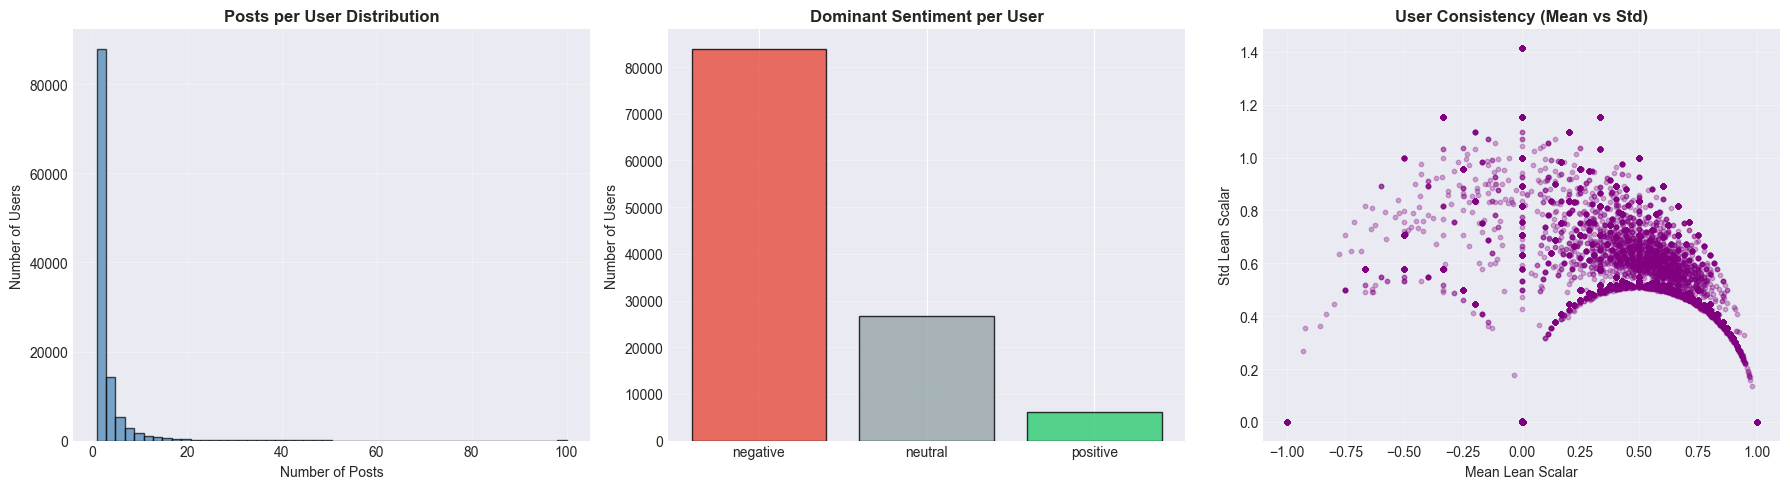

In [58]:
# 5b. User Stats Diagnostics (aggregate_user_stats)

def aggregate_user_stats(content_df, user_col='user', proba_cols=('p_neg', 'p_neu', 'p_pos')):
    """Diagnostic per-user statistics."""
    df_c = content_df.copy()
    p_neg, p_neu, p_pos = [df_c[c].astype(float).values for c in proba_cols]
    eps = 1e-12
    s = p_neg + p_neu + p_pos + eps
    p_neg, p_neu, p_pos = p_neg/s, p_neu/s, p_pos/s
    df_c["lean_scalar"] = 1.0*p_neg + 0.0*p_neu + (-1.0)*p_pos
    df_c["_p_neg"], df_c["_p_neu"], df_c["_p_pos"] = p_neg, p_neu, p_pos
    labels = np.array(['negative', 'neutral', 'positive'])
    P = np.vstack([p_neg, p_neu, p_pos]).T
    df_c["_dominant"] = labels[np.argmax(P, axis=1)]

    agg = df_c.groupby(user_col).agg(
        n_posts=(user_col, 'count'),
        lean_scalar=('lean_scalar', 'mean'),
        lean_std=('lean_scalar', 'std'),
        p_neg_mean=('_p_neg', 'mean'),
        p_neu_mean=('_p_neu', 'mean'),
        p_pos_mean=('_p_pos', 'mean'),
        dominant_sentiment=('_dominant', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'neutral'),
    ).reset_index()
    agg['lean_std'] = agg['lean_std'].fillna(0)
    return agg

user_stats = aggregate_user_stats(content, user_col='user')

print("=== USER STATS DIAGNOSTICS ===")
print(f"\nDistribusi jumlah posts per user:")
print(user_stats['n_posts'].describe())

print(f"\nDominant sentiment distribution:")
print(user_stats['dominant_sentiment'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(user_stats['n_posts'].clip(0, 100), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Number of Posts')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Posts per User Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3)

dom_counts = user_stats['dominant_sentiment'].value_counts()
colors_dom = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}
axes[1].bar(dom_counts.index, dom_counts.values,
            color=[colors_dom.get(s, 'gray') for s in dom_counts.index], alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Dominant Sentiment per User', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].scatter(user_stats['lean_scalar'], user_stats['lean_std'], alpha=0.3, s=10, c='purple')
axes[2].set_xlabel('Mean Lean Scalar')
axes[2].set_ylabel('Std Lean Scalar')
axes[2].set_title('User Consistency (Mean vs Std)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Community Detection

Using resolution: 4.963
Communities detected: 352

Top 10 community sizes:
0    4213
1    4058
2    3193
3    3065
4    3000
5    2606
6    2601
7    2589
8    2360
9    2358
Name: count, dtype: int64


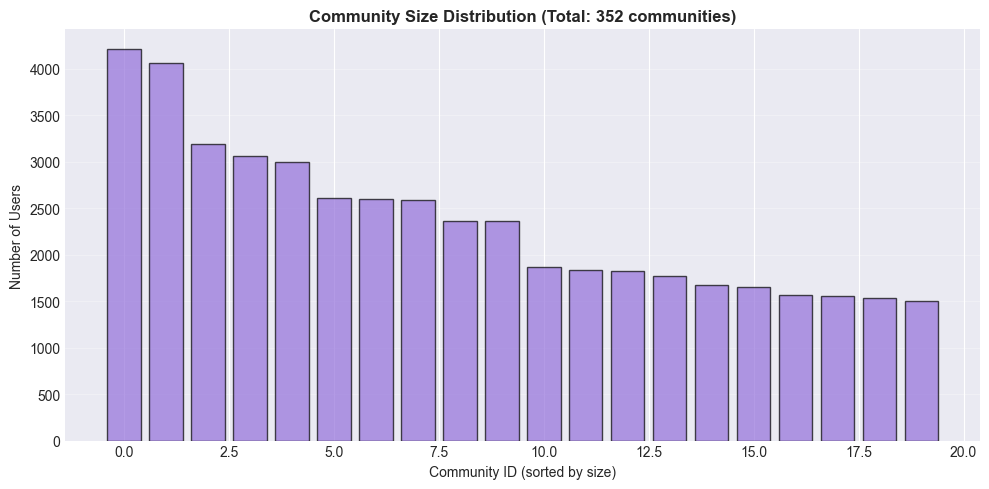

In [59]:
def detect_communities(
    G, method: str = "leiden", resolution: float = 1.0, random_state: int = 42
) -> Dict[str, int]:
    if method == "leiden" and _HAS_LEIDEN:
        mapping = {n: i for i, n in enumerate(G.nodes())}
        inv = {i: n for n, i in mapping.items()}
        edges = [(mapping[u], mapping[v]) for u, v in G.edges()]
        ig_g = ig.Graph(n=len(G), edges=edges, directed=isinstance(G, nx.DiGraph))
        if isinstance(G, nx.DiGraph):
            ig_g.to_undirected(mode="collapse")
        partition = la.find_partition(
            ig_g, la.RBConfigurationVertexPartition,
            resolution_parameter=resolution, seed=random_state
        )
        return {inv[i]: partition.membership[i] for i in range(len(G))}
    else:
        print(f"WARNING: Leiden method not available. Falling back to Louvain (undirected).")
        G_und = G.to_undirected() if isinstance(G, nx.DiGraph) else G
        try:
            partition = nx.community.louvain_communities(G_und, seed=random_state, resolution=resolution)
            result = {}
            for cid, nodes in enumerate(partition):
                for node in nodes:
                    result[node] = cid
            return result
        except:
            return {n: 0 for n in G.nodes()}

resolution = max(0.5, np.log10(n_nodes + 1))
print(f"Using resolution: {resolution:.3f}")

communities = detect_communities(G, method='leiden', resolution=resolution, random_state=42)

n_communities = len(set(communities.values()))
comm_sizes = pd.Series(communities.values()).value_counts().sort_values(ascending=False)

print(f"Communities detected: {n_communities}")
print(f"\nTop 10 community sizes:")
print(comm_sizes.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(min(20, len(comm_sizes))), comm_sizes.values[:20], color='mediumpurple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Community ID (sorted by size)')
ax.set_ylabel('Number of Users')
ax.set_title(f'Community Size Distribution (Total: {n_communities} communities)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('03_community_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Homophily & ECR 2.0 Computation

**ECR 2.0 = E[intra-community] / E[inter-community]**

In [60]:
def compute_homophily(G, df_users, lean_col="lean_scalar"):
    lean = dict(zip(df_users["user"], df_users[lean_col]))
    neigh_mean = {}
    
    for u in G.nodes():
        nbrs = list(G.successors(u)) + list(G.predecessors(u)) if isinstance(G, nx.DiGraph) else list(G.neighbors(u))
        vals = [lean[v] for v in nbrs if v in lean and not np.isnan(lean[v])]
        neigh_mean[u] = float(np.mean(vals)) if vals else np.nan
    
    a, b = [], []
    for u in G.nodes():
        lu = lean.get(u, np.nan)
        mv = neigh_mean.get(u, np.nan)
        if not (np.isnan(lu) or np.isnan(mv)):
            a.append(lu); b.append(mv)
    
    r = float(np.corrcoef(a, b)[0, 1]) if len(a) >= 3 else float("nan")
    return {"neighbor_mean": neigh_mean, "pearson_r": r, "n_pairs": len(a)}


@dataclass
class ECR2Result:
    intra: float
    inter: float
    ratio: float
    homophily_r: float


def compute_ecr2(G, df_users, communities, lean_col="lean_scalar",
                 sample_edges=None, random_state=42) -> ECR2Result:
    lean = dict(zip(df_users["user"], df_users[lean_col]))
    edges = list(G.edges())
    
    if sample_edges and sample_edges < len(edges):
        rng = np.random.RandomState(random_state)
        idx = rng.choice(len(edges), size=sample_edges, replace=False)
        edges = [edges[i] for i in idx]
    
    intra_vals, inter_vals = [], []
    n_skipped = 0
    
    for u, v in edges:
        lu, lv = lean.get(u, np.nan), lean.get(v, np.nan)
        if np.isnan(lu) or np.isnan(lv):
            n_skipped += 1
            continue
        
        cu, cv = communities.get(u), communities.get(v)
        agreement = 1.0 - abs(lu - lv) / 2.0
        
        if cu is not None and cv is not None and cu == cv:
            intra_vals.append(agreement)
        else:
            inter_vals.append(agreement)
    
    intra = float(np.nanmean(intra_vals)) if intra_vals else float("nan")
    inter = float(np.nanmean(inter_vals)) if inter_vals else float("nan")
    ratio = float(intra / inter) if (inter > 0 and not np.isnan(inter)) else float("nan")
    
    homo = compute_homophily(G, df_users)
    
    print(f"  Edges processed: {len(intra_vals) + len(inter_vals):,} (skipped {n_skipped:,} due to missing leaning)")
    print(f"  Intra-community edges: {len(intra_vals):,}")
    print(f"  Inter-community edges: {len(inter_vals):,}")
    
    return ECR2Result(intra=intra, inter=inter, ratio=ratio, homophily_r=homo["pearson_r"])

In [61]:
print("Computing homophily...")
homophily = compute_homophily(G, df_users)
print(f"Homophily (Pearson r): {homophily['pearson_r']:.4f}")
print(f"Pairs used: {homophily['n_pairs']:,}")

print("\nComputing ECR 2.0...")
ecr2 = compute_ecr2(G, df_users, communities)

print(f"ECR 2.0 RESULTS")
print(f"Intra-community agreement : {ecr2.intra:.4f}")
print(f"Inter-community agreement : {ecr2.inter:.4f}")
print(f"ECR Ratio                 : {ecr2.ratio:.4f}")
print(f"Homophily (Pearson r)     : {ecr2.homophily_r:.4f}")

Computing homophily...
Homophily (Pearson r): 0.1005
Pairs used: 91,784

Computing ECR 2.0...
  Edges processed: 194,491 (skipped 0 due to missing leaning)
  Intra-community edges: 103,102
  Inter-community edges: 91,389
ECR 2.0 RESULTS
Intra-community agreement : 0.7751
Inter-community agreement : 0.8550
ECR Ratio                 : 0.9065
Homophily (Pearson r)     : 0.1005


---
## 8. Threshold Estimation & Classification

In [62]:
def _randomize_graph_preserve_degree(G, n_swap=None, seed=42):
    """n_swap defaults to max(|E|, 5000) for thorough randomization."""
    H = copy.deepcopy(G)
    if n_swap is None:
        n_swap = max(H.number_of_edges(), 5_000)
    try:
        if isinstance(G, nx.DiGraph):
            nx.algorithms.swap.directed_edge_swap(H, nswap=n_swap, max_tries=n_swap*10, seed=seed)
        else:
            nx.algorithms.swap.double_edge_swap(H, nswap=n_swap, max_tries=n_swap*10, seed=seed)
    except nx.NetworkXAlgorithmError:
        pass
    return H

def estimate_ecr_threshold(G, df_users, communities, n_samples=100, seed=42) -> float:
    """Null model: randomize graph edges (preserving degree), compute ECR distribution.
    threshold = mean + 1*std of null distribution.
    Uses n_samples=100 for reliable null distribution and n_swap=|E| for thorough randomization.
    """
    rng = random.Random(seed)
    vals = []
    for i in tqdm(range(n_samples), desc="Null model sampling"):
        H = _randomize_graph_preserve_degree(G, seed=rng.randint(1, 10**9))
        res = compute_ecr2(H, df_users, communities)
        if not math.isnan(res.ratio) and res.ratio > 0:
            vals.append(min(2.0, res.ratio))  # cap at 2
    if len(vals) < 3:
        return 1.0
    return float(np.clip(np.mean(vals) + np.std(vals), 0.0, 2.0))

def classify_echo_chamber(ecr_ratio: float, threshold: float) -> str:
    if math.isnan(ecr_ratio):
        return "Tidak dapat ditentukan (ECR NaN)"
    if ecr_ratio > threshold:
        return "FENOMENA ECHO CHAMBER"
    else:
        return "FENOMENA NON-ECHO CHAMBER"

print("Estimating empirical threshold...")
print(f"  Graph has {G.number_of_edges():,} edges -> n_swap = {max(G.number_of_edges(), 5000):,}")
threshold = estimate_ecr_threshold(G, df_users, communities, n_samples=100, seed=42)
classification = classify_echo_chamber(ecr2.ratio, threshold)

print(f"FINAL RESULT")
print(f"ECR Ratio    : {ecr2.ratio:.4f}")
print(f"Threshold    : {threshold:.4f}")
print(f"Kesimpulan   : {classification}")

Estimating empirical threshold...
  Graph has 194,491 edges -> n_swap = 194,491


Null model sampling:   1%|          | 1/100 [00:04<07:29,  4.54s/it]

  Edges processed: 194,491 (skipped 0 due to missing leaning)
  Intra-community edges: 63,907
  Inter-community edges: 130,584


Null model sampling:   2%|▏         | 2/100 [00:09<07:45,  4.75s/it]

  Edges processed: 194,491 (skipped 0 due to missing leaning)
  Intra-community edges: 64,315
  Inter-community edges: 130,176


...

  Edges processed: 194,491 (skipped 0 due to missing leaning)
  Intra-community edges: 64,040
  Inter-community edges: 130,451


Null model sampling:  99%|█████████▉| 99/100 [08:01<00:05,  5.02s/it]

  Edges processed: 194,491 (skipped 0 due to missing leaning)
  Intra-community edges: 64,088
  Inter-community edges: 130,403


Null model sampling: 100%|██████████| 100/100 [08:06<00:00,  4.87s/it]

  Edges processed: 194,491 (skipped 0 due to missing leaning)
  Intra-community edges: 63,950
  Inter-community edges: 130,541
FINAL RESULT
ECR Ratio    : 0.9065
Threshold    : 0.9240
Kesimpulan   : FENOMENA NON-ECHO CHAMBER


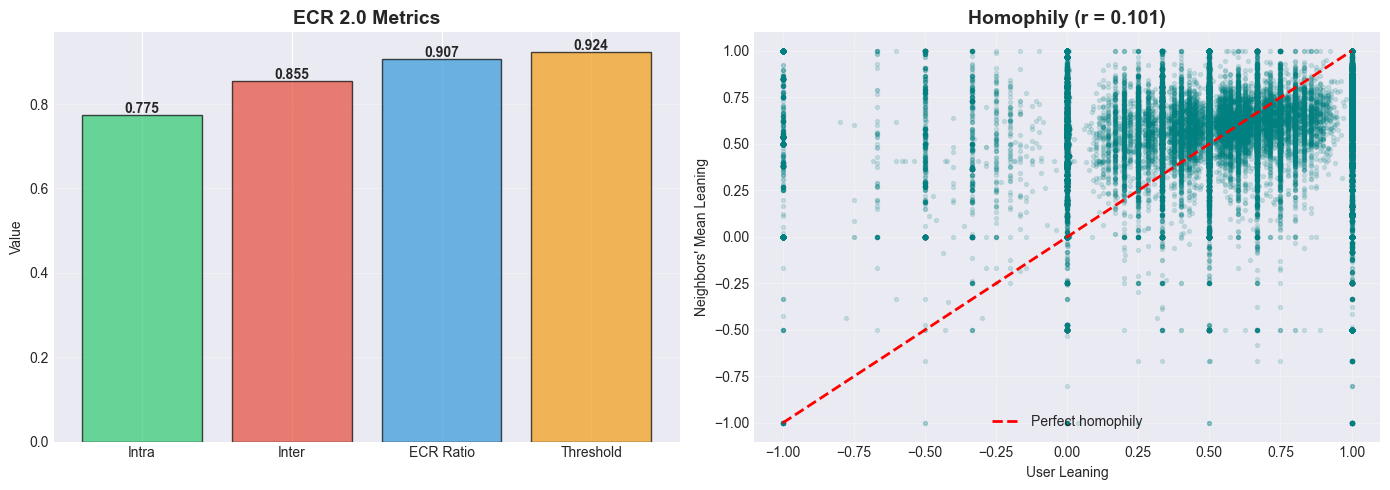

In [63]:
# Visualisasi ECR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Intra', 'Inter', 'ECR Ratio', 'Threshold']
values = [ecr2.intra, ecr2.inter, ecr2.ratio, threshold]
colors = ['#2ecc71', '#e74c3c', '#3498db' if ecr2.ratio <= threshold else '#e74c3c', '#f39c12']

bars = axes[0].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].set_title('ECR 2.0 Metrics', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

lean = dict(zip(df_users["user"], df_users["lean_scalar"]))
nm = homophily["neighbor_mean"]
x_v, y_v = [], []
for u in G.nodes():
    lu, mv = lean.get(u, np.nan), nm.get(u, np.nan)
    if not (np.isnan(lu) or np.isnan(mv)):
        x_v.append(lu); y_v.append(mv)
axes[1].scatter(x_v, y_v, alpha=0.15, s=8, c='teal')
axes[1].plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect homophily')
axes[1].set_xlabel('User Leaning')
axes[1].set_ylabel("Neighbors' Mean Leaning")
axes[1].set_title(f'Homophily (r = {ecr2.homophily_r:.3f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_ecr_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8.5 GDM Cosine Consensus (Pembanding ECR Agreement Kernel)

Membandingkan dua cara mengukur similarity antar user:
1. **Agreement kernel** (pipeline utama): `agreement(u,v) = 1 - |lean_u - lean_v| / 2`
2. **Cosine similarity** (GDM-style): `cos(proba_u, proba_v)` pada vektor probabilitas [p_neg, p_neu, p_pos]

Kedua metrik dihitung pada komunitas **Leiden yang sama** untuk melihat apakah kesimpulan ECR robust terhadap pilihan similarity measure.

=== PERBANDINGAN: Agreement Kernel vs Cosine Consensus ===

Method                 |    Intra |    Inter |  ECR Ratio
----------------------------------------------------------
Agreement kernel       |   0.7751 |   0.8550 |     0.9065
Cosine consensus       |   0.7182 |   0.8562 |     0.8388

[OK] Kedua metrik menunjukkan arah yang KONSISTEN (ECR <= 1 = no echo chamber)


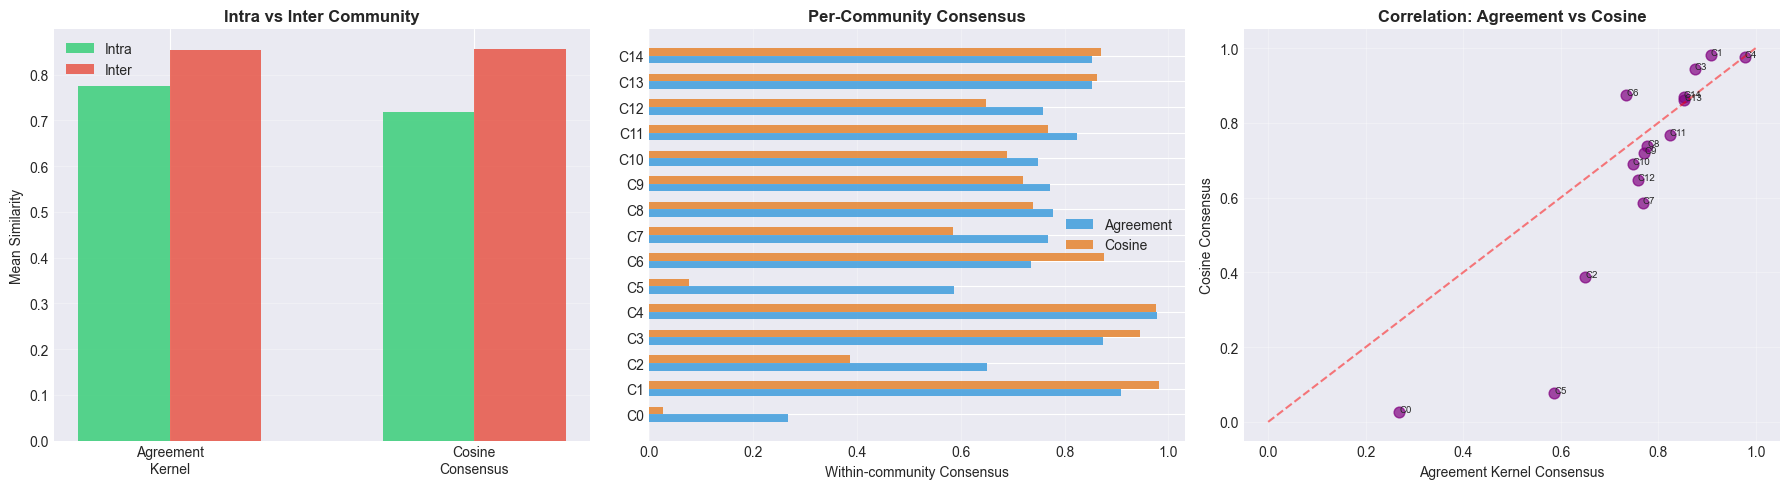

In [64]:
# 8.5a. Compute GDM Cosine Consensus

def cosine_similarity_vectors(v1, v2):
    """Cosine similarity between two probability vectors."""
    v1, v2 = np.asarray(v1, dtype=float), np.asarray(v2, dtype=float)
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 < 1e-12 or n2 < 1e-12:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))

# Build per-user probability vectors
user_proba = {}
for _, row in df_users.iterrows():
    uid = row['user']
    user_proba[uid] = np.array([
        row.get('p_neg_mean', 0.33),
        row.get('p_neu_mean', 0.33),
        row.get('p_pos_mean', 0.33),
    ], dtype=float)

# Per-edge cosine similarity
intra_cosine_vals, inter_cosine_vals = [], []
for u, v in G.edges():
    if u not in user_proba or v not in user_proba:
        continue
    cu, cv = communities.get(u), communities.get(v)
    sim = cosine_similarity_vectors(user_proba[u], user_proba[v])
    if cu is not None and cv is not None and cu == cv:
        intra_cosine_vals.append(sim)
    else:
        inter_cosine_vals.append(sim)

intra_cosine = float(np.mean(intra_cosine_vals)) if intra_cosine_vals else float('nan')
inter_cosine = float(np.mean(inter_cosine_vals)) if inter_cosine_vals else float('nan')
ecr_cosine = intra_cosine / inter_cosine if inter_cosine > 0 else float('nan')

print("=== PERBANDINGAN: Agreement Kernel vs Cosine Consensus ===\n")
print(f"{'Method':<22} | {'Intra':>8} | {'Inter':>8} | {'ECR Ratio':>10}")
print("-" * 58)
print(f"{'Agreement kernel':<22} | {ecr2.intra:>8.4f} | {ecr2.inter:>8.4f} | {ecr2.ratio:>10.4f}")
print(f"{'Cosine consensus':<22} | {intra_cosine:>8.4f} | {inter_cosine:>8.4f} | {ecr_cosine:>10.4f}")

if ecr2.ratio > 1.0 and ecr_cosine > 1.0:
    print("\n[OK] Kedua metrik menunjukkan arah yang KONSISTEN (ECR > 1 = echo chamber signal)")
elif ecr2.ratio <= 1.0 and ecr_cosine <= 1.0:
    print("\n[OK] Kedua metrik menunjukkan arah yang KONSISTEN (ECR <= 1 = no echo chamber)")
else:
    print("\n[!] Kedua metrik menunjukkan arah BERBEDA -- perlu investigasi lebih lanjut")

# Per-community within-consensus (cosine)
comm_members = defaultdict(list)
for user, cid in communities.items():
    if user in user_proba:
        comm_members[cid].append(user)

per_comm_cosine = {}
for cid, members in comm_members.items():
    if len(members) < 2:
        continue
    sims = []
    for i in range(len(members)):
        for j in range(i+1, len(members)):
            u, v = members[i], members[j]
            if G.has_edge(u, v) or G.has_edge(v, u):
                sims.append(cosine_similarity_vectors(user_proba[u], user_proba[v]))
    if sims:
        per_comm_cosine[cid] = float(np.mean(sims))

# Per-community agreement kernel (for comparison)
lean_dict = dict(zip(df_users['user'], df_users['lean_scalar']))
per_comm_agreement = {}
for cid, members in comm_members.items():
    if len(members) < 2:
        continue
    agrs = []
    for i in range(len(members)):
        for j in range(i+1, len(members)):
            u, v = members[i], members[j]
            if G.has_edge(u, v) or G.has_edge(v, u):
                lu, lv = lean_dict.get(u, np.nan), lean_dict.get(v, np.nan)
                if not np.isnan(lu) and not np.isnan(lv):
                    agrs.append(1.0 - abs(lu - lv) / 2.0)
    if agrs:
        per_comm_agreement[cid] = float(np.mean(agrs))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart comparison
methods = ['Agreement\nKernel', 'Cosine\nConsensus']
intras = [ecr2.intra, intra_cosine]
inters = [ecr2.inter, inter_cosine]
x = np.arange(2)
w = 0.3
axes[0].bar(x - w/2, intras, w, label='Intra', color='#2ecc71', alpha=0.8)
axes[0].bar(x + w/2, inters, w, label='Inter', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel('Mean Similarity')
axes[0].set_title('Intra vs Inter Community', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Per-community side-by-side
common_comms = sorted(set(per_comm_cosine.keys()) & set(per_comm_agreement.keys()))[:15]
if common_comms:
    y_pos = np.arange(len(common_comms))
    agr_vals = [per_comm_agreement.get(c, 0) for c in common_comms]
    cos_vals = [per_comm_cosine.get(c, 0) for c in common_comms]
    axes[1].barh(y_pos - 0.15, agr_vals, 0.3, label='Agreement', color='#3498db', alpha=0.8)
    axes[1].barh(y_pos + 0.15, cos_vals, 0.3, label='Cosine', color='#e67e22', alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels([f'C{c}' for c in common_comms])
    axes[1].set_xlabel('Within-community Consensus')
    axes[1].set_title('Per-Community Consensus', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='x')

# Scatter: agreement vs cosine per community
if common_comms:
    axes[2].scatter(agr_vals, cos_vals, s=60, c='purple', alpha=0.7)
    for i, c in enumerate(common_comms):
        axes[2].annotate(f'C{c}', (agr_vals[i], cos_vals[i]), fontsize=7)
    axes[2].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[2].set_xlabel('Agreement Kernel Consensus')
    axes[2].set_ylabel('Cosine Consensus')
    axes[2].set_title('Correlation: Agreement vs Cosine', fontweight='bold')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Diffusion Bias  --  Independent Cascade

Running IC simulation...


Simulated 91,784 seed users


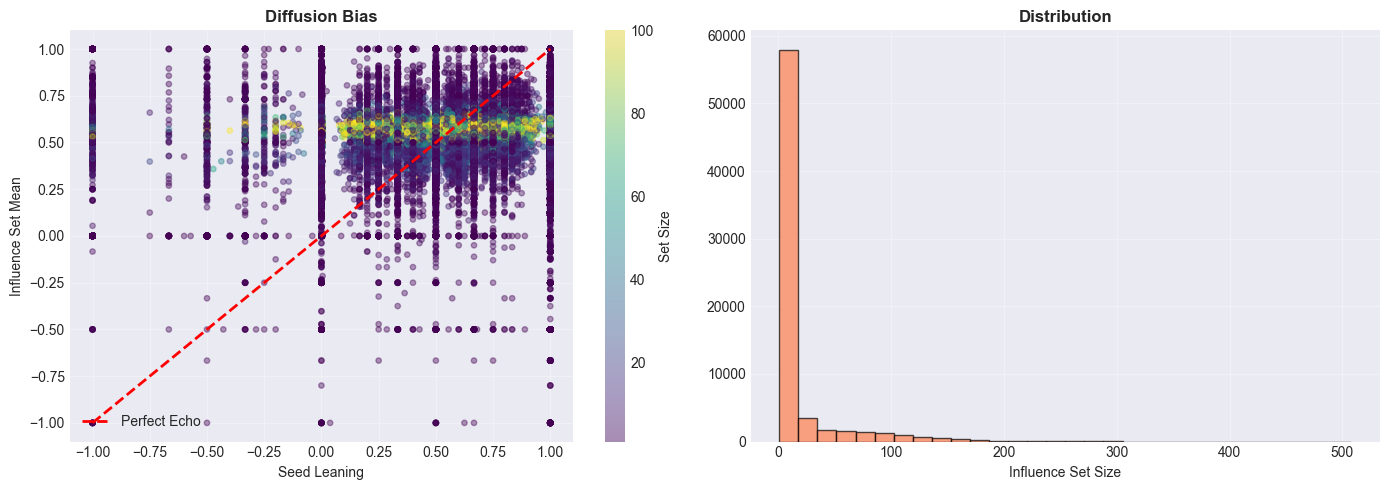

In [65]:
def _ic_run(G, seed_node, p_activate, rng):
    active = {seed_node}
    frontier = [seed_node]
    while frontier:
        u = frontier.pop()
        for v in G.successors(u):
            if v in active:
                continue
            w = float(G[u][v].get("weight", 1.0))
            p = 1.0 - (1.0 - p_activate) ** max(1.0, w)
            if rng.random() < p:
                active.add(v)
                frontier.append(v)
    return active

def simulate_diffusion_bias(G, df_users, p_activate=0.05, n_runs=20, seed=42):
    if isinstance(G, nx.Graph) and not isinstance(G, nx.DiGraph):
        G = nx.DiGraph(G)
    lean = dict(zip(df_users["user"], df_users["lean_scalar"]))
    rows = []
    rng = random.Random(seed)
    for s in tqdm(list(G.nodes()), desc="IC simulate", leave=False):
        seed_lean = lean.get(s, np.nan)
        if np.isnan(seed_lean):
            continue
        union = set()
        for _ in range(n_runs):
            union |= _ic_run(G, s, p_activate, rng)
        union.discard(s)
        vals = [lean[v] for v in union if v in lean and not np.isnan(lean[v])]
        rows.append({
            "seed": s, "seed_lean": seed_lean,
            "infl_mean": float(np.mean(vals)) if vals else np.nan,
            "infl_size": len(vals)
        })
    return pd.DataFrame(rows)

print("Running IC simulation...")
ic_rows = simulate_diffusion_bias(G, df_users, p_activate=0.05, n_runs=20, seed=42)
print(f"Simulated {len(ic_rows):,} seed users")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ic_valid = ic_rows.dropna(subset=['infl_mean'])
sc = axes[0].scatter(ic_valid['seed_lean'], ic_valid['infl_mean'],
                     c=ic_valid['infl_size'].clip(0, 100), cmap='viridis', alpha=0.4, s=15)
axes[0].plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Perfect Echo')
axes[0].set_xlabel('Seed Leaning'); axes[0].set_ylabel('Influence Set Mean')
axes[0].set_title('Diffusion Bias', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
plt.colorbar(sc, ax=axes[0], label='Set Size')

axes[1].hist(ic_valid['infl_size'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Influence Set Size'); axes[1].set_title('Distribution', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('05_diffusion_bias.png', dpi=150, bbox_inches='tight'); plt.show()

### 9.5 Metrik Kuantitatif Bias Difusi

Selain scatter plot, kita menghitung:
- **Global**: Linear regression (slope, R², p-value), bias ratio, paired t-test, Cohen's d
- **Per-community**: slope, R², one-sample t-test apakah bias ≠ 0

=== GLOBAL DIFFUSION BIAS METRICS ===

  Linear Regression:
    slope     = 0.0754
    intercept = 0.4846
    R²        = 0.0128
    p-value   = 2.19e-200
    std_err   = 0.0025

  Bias Ratio  = 0.8649
  Paired t-test: t=24.5396, p=2.00e-132
  Cohen's d   = -0.0923

  [*] Slope signifikan (p < 0.05): ada hubungan linear seed_lean -> infl_mean

=== PER-COMMUNITY DIFFUSION METRICS (Top 15) ===
 community  n_seeds  mean_seed_lean  mean_infl_mean      bias     slope  r_squared       ttest_p
         1     2853        0.982618        0.805632 -0.176986  0.007406   0.000243  0.000000e+00
         2     2781        0.034423        0.707240  0.672817 -0.108706   0.030220  0.000000e+00
         0     2757        0.965418       -0.468392 -1.433810 -0.280768   0.068098  0.000000e+00
         3     2133        0.973352        0.708077 -0.265275  0.122185   0.006262  0.000000e+00
         4     2012        0.948139        0.929327 -0.018812  0.264435   0.067542  3.256045e-05
         5     1826    

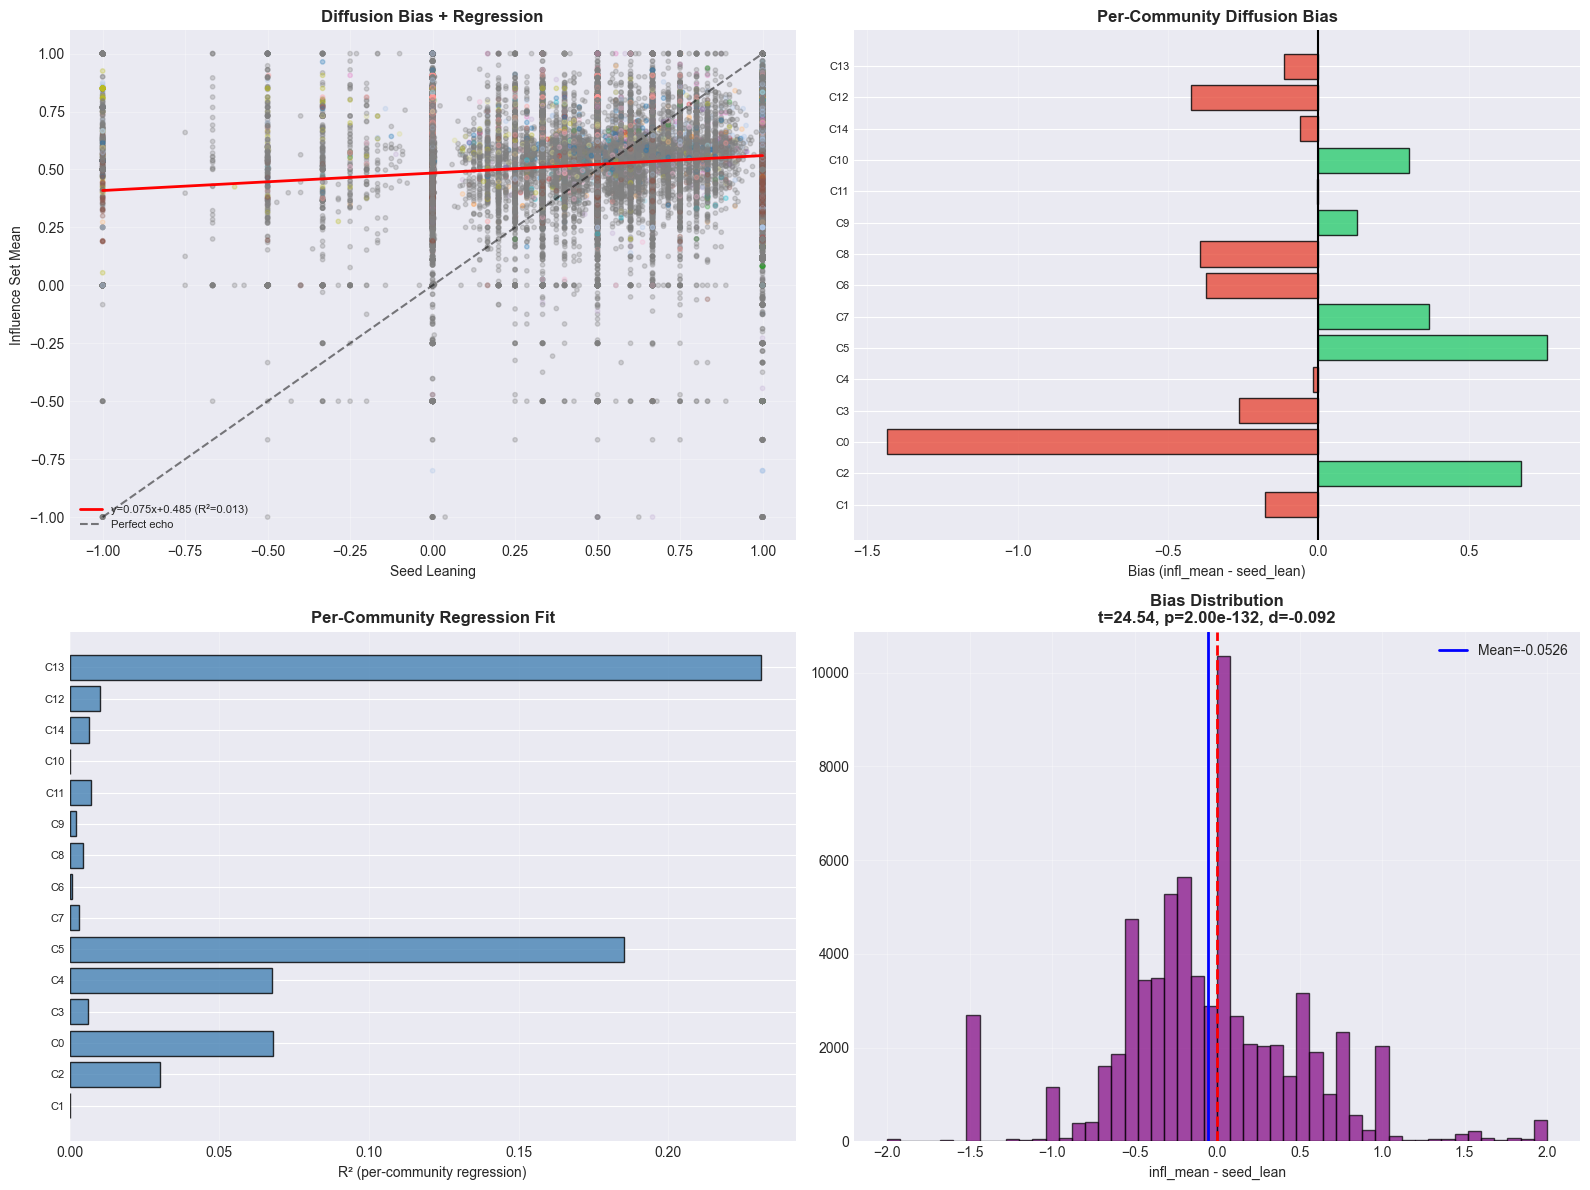

Saved: 05_diffusion_bias.png


In [66]:
# 9.5a. Compute diffusion bias metrics

def _safe_linregress(x, y):
    """linregress that handles constant x (all identical values)."""
    if np.std(x) < 1e-12:
        return 0.0, float(np.mean(y)), 0.0, 1.0, 0.0
    return scipy_stats.linregress(x, y)

ic_valid = ic_rows.dropna(subset=['seed_lean', 'infl_mean']).copy()
x_diff = ic_valid['seed_lean'].values
y_diff = ic_valid['infl_mean'].values

# Global metrics
slope, intercept, r_value, p_value, std_err = _safe_linregress(x_diff, y_diff)
bias_ratio = np.mean(np.abs(y_diff)) / max(np.mean(np.abs(x_diff)), 1e-12)

if len(x_diff) >= 3 and np.std(x_diff - y_diff) > 1e-12:
    t_stat, t_pvalue = scipy_stats.ttest_rel(x_diff, y_diff)
else:
    t_stat, t_pvalue = 0.0, 1.0

diff_vals = y_diff - x_diff
cohens_d = float(np.mean(diff_vals) / max(np.std(diff_vals, ddof=1), 1e-12))

print("=== GLOBAL DIFFUSION BIAS METRICS ===\n")
print(f"  Linear Regression:")
print(f"    slope     = {slope:.4f}")
print(f"    intercept = {intercept:.4f}")
print(f"    R²        = {r_value**2:.4f}")
print(f"    p-value   = {p_value:.2e}")
print(f"    std_err   = {std_err:.4f}")
print(f"\n  Bias Ratio  = {bias_ratio:.4f}")
print(f"  Paired t-test: t={t_stat:.4f}, p={t_pvalue:.2e}")
print(f"  Cohen's d   = {cohens_d:.4f}")

if p_value < 0.05:
    print(f"\n  [*] Slope signifikan (p < 0.05): ada hubungan linear seed_lean -> infl_mean")
else:
    print(f"\n  [ ] Slope TIDAK signifikan (p >= 0.05)")

# Per-community metrics
ic_valid['community'] = ic_valid['seed'].map(communities)
comm_diff_rows = []

for cid, cdf in ic_valid.groupby('community'):
    if len(cdf) < 5:
        continue
    cx, cy = cdf['seed_lean'].values, cdf['infl_mean'].values
    c_slope, c_int, c_r, c_p, c_se = _safe_linregress(cx, cy)
    c_bias = cy - cx
    if np.std(c_bias) > 1e-12 and len(c_bias) >= 3:
        c_t, c_tp = scipy_stats.ttest_1samp(c_bias, 0)
    else:
        c_t, c_tp = 0.0, 1.0
    comm_diff_rows.append({
        'community': cid, 'n_seeds': len(cdf),
        'mean_seed_lean': float(np.mean(cx)), 'mean_infl_mean': float(np.mean(cy)),
        'bias': float(np.mean(c_bias)), 'slope': float(c_slope),
        'r_squared': float(c_r**2), 'ttest_p': float(c_tp),
    })

df_diff_comm = pd.DataFrame(comm_diff_rows).sort_values('n_seeds', ascending=False)
print("\n=== PER-COMMUNITY DIFFUSION METRICS (Top 15) ===")
print(df_diff_comm.head(15).to_string(index=False))

# 9.5b. Visualizations (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Scatter + regression line, colored by community
comm_colors = {}
unique_comms = ic_valid['community'].dropna().unique()
cmap_arr = plt.cm.tab20(np.linspace(0, 1, min(20, len(unique_comms))))
for i, c in enumerate(unique_comms[:20]):
    comm_colors[c] = cmap_arr[i]

colors = [comm_colors.get(c, (0.5, 0.5, 0.5, 0.5)) for c in ic_valid['community']]
axes[0, 0].scatter(x_diff, y_diff, c=colors, alpha=0.3, s=10)
x_line = np.linspace(-1, 1, 100)
axes[0, 0].plot(x_line, slope * x_line + intercept, 'r-', linewidth=2,
                label=f'y={slope:.3f}x+{intercept:.3f} (R²={r_value**2:.3f})')
axes[0, 0].plot([-1, 1], [-1, 1], 'k--', alpha=0.5, label='Perfect echo')
axes[0, 0].set_xlabel('Seed Leaning')
axes[0, 0].set_ylabel('Influence Set Mean')
axes[0, 0].set_title('Diffusion Bias + Regression', fontweight='bold')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 2) Per-community bias bar chart
top_comms = df_diff_comm.head(15)
y_pos = np.arange(len(top_comms))
colors_bar = ['#2ecc71' if b > 0 else '#e74c3c' for b in top_comms['bias']]
axes[0, 1].barh(y_pos, top_comms['bias'].values, color=colors_bar, alpha=0.8, edgecolor='black')
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels([f"C{int(c)}" for c in top_comms['community']], fontsize=8)
axes[0, 1].axvline(x=0, color='black', linestyle='-')
axes[0, 1].set_xlabel('Bias (infl_mean - seed_lean)')
axes[0, 1].set_title('Per-Community Diffusion Bias', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3) Per-community R² bar chart
axes[1, 0].barh(y_pos, top_comms['r_squared'].values, color='steelblue', alpha=0.8, edgecolor='black')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([f"C{int(c)}" for c in top_comms['community']], fontsize=8)
axes[1, 0].set_xlabel('R² (per-community regression)')
axes[1, 0].set_title('Per-Community Regression Fit', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4) Histogram of (
# infl_mean - seed_lean) + t-test annotation
axes[1, 1].hist(diff_vals, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(x=np.mean(diff_vals), color='blue', linestyle='-', linewidth=2,
                    label=f'Mean={np.mean(diff_vals):.4f}')
axes[1, 1].set_xlabel('infl_mean - seed_lean')
axes[1, 1].set_title(f'Bias Distribution\nt={t_stat:.2f}, p={t_pvalue:.2e}, d={cohens_d:.3f}',
                      fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_diffusion_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_diffusion_bias.png")

---
## 10. Community Analysis: Pro vs Contra

In [67]:
# 10a. Classify communities
def classify_communities_by_stance(G, df_users, communities, lean_col="lean_scalar", threshold=0.2):
    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    community_leaning = defaultdict(list)
    for user, comm_id in communities.items():
        if user in lean_dict and not np.isnan(lean_dict[user]):
            community_leaning[comm_id].append(lean_dict[user])
    community_stance = {}
    for comm_id, leanings in community_leaning.items():
        avg = np.mean(leanings)
        if avg > threshold: community_stance[comm_id] = 'pro'
        elif avg < -threshold: community_stance[comm_id] = 'contra'
        else: community_stance[comm_id] = 'neutral'
    return community_stance

def analyze_pro_contra_communities(G, df_users, communities, lean_col="lean_scalar", threshold=0.2):
    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    community_stance = classify_communities_by_stance(G, df_users, communities, lean_col, threshold)
    results = []
    for comm_id in set(communities.values()):
        members = [u for u, c in communities.items() if c == comm_id]
        leanings = [lean_dict.get(u, np.nan) for u in members]
        leanings = [x for x in leanings if not np.isnan(x)]
        if not leanings: continue
        internal = external = 0
        for u in members:
            if u in G:
                for v in (G.successors(u) if isinstance(G, nx.DiGraph) else G.neighbors(u)):
                    if communities.get(v) == comm_id: internal += 1
                    else: external += 1
        results.append({
            'community_id': comm_id, 'stance': community_stance.get(comm_id, 'neutral'),
            'size': len(members), 'avg_leaning': np.mean(leanings), 'std_leaning': np.std(leanings),
            'internal_edges': internal, 'external_edges': external,
            'modularity': internal / (internal + external) if (internal + external) > 0 else 0
        })
    return pd.DataFrame(results).sort_values('size', ascending=False)

community_stance = classify_communities_by_stance(G, df_users, communities)
df_communities = analyze_pro_contra_communities(G, df_users, communities)

stance_counts = pd.Series(community_stance.values()).value_counts()
print("Distribusi Community Stance:")
print(stance_counts)
print(f"\nTop 15 communities:")
print(df_communities[['community_id', 'stance', 'size', 'avg_leaning', 'modularity']].head(15))

Distribusi Community Stance:
pro        303
neutral     38
contra      11
Name: count, dtype: int64

Top 15 communities:
    community_id   stance  size  avg_leaning  modularity
0              0      pro  4213     0.965306    0.967838
1              1      pro  4058     0.983045    0.993635
2              2  neutral  3193     0.034475    0.931447
3              3      pro  3065     0.976534    0.893326
4              4      pro  3000     0.956341    0.880247
5              5   contra  2606    -0.723550    0.827302
6              6      pro  2601     0.936364    0.947598
7              7  neutral  2589     0.171017    0.834569
8              8      pro  2360     0.912190    0.813168
9              9      pro  2358     0.335150    0.992024
10            10      pro  1868     0.259416    0.719944
11            11      pro  1831     0.405805    0.580818
12            12      pro  1825     0.856094    0.701808
13            13      pro  1766     0.780077    0.715183
14            14      pr

=== DETAILED COMMUNITY CLASSIFICATION ===
 community_id  size  stance  avg_leaning  std_leaning  pct_pro  pct_contra  pct_neutral  confidence
            0  4213     pro     0.965306     0.164163 0.979824    0.001187     0.018989    5.880153
            1  4058     pro     0.983045     0.114986 0.991868    0.000493     0.007639    8.549292
            2  3193 neutral     0.034475     0.127266 0.099593    0.010335     0.890072    0.270892
            3  3065     pro     0.976534     0.111747 0.997716    0.000326     0.001958    8.738800
            4  3000     pro     0.956341     0.152881 0.994000    0.001000     0.005000    6.255461
            5  2606  contra    -0.723550     0.522618 0.072525    0.820798     0.106677    1.384472
            6  2601     pro     0.936364     0.205805 0.972703    0.000384     0.026913    4.549770
            7  2589 neutral     0.171017     0.301807 0.289687    0.007725     0.702588    0.566645
            8  2360     pro     0.912190     0.223466 0.97

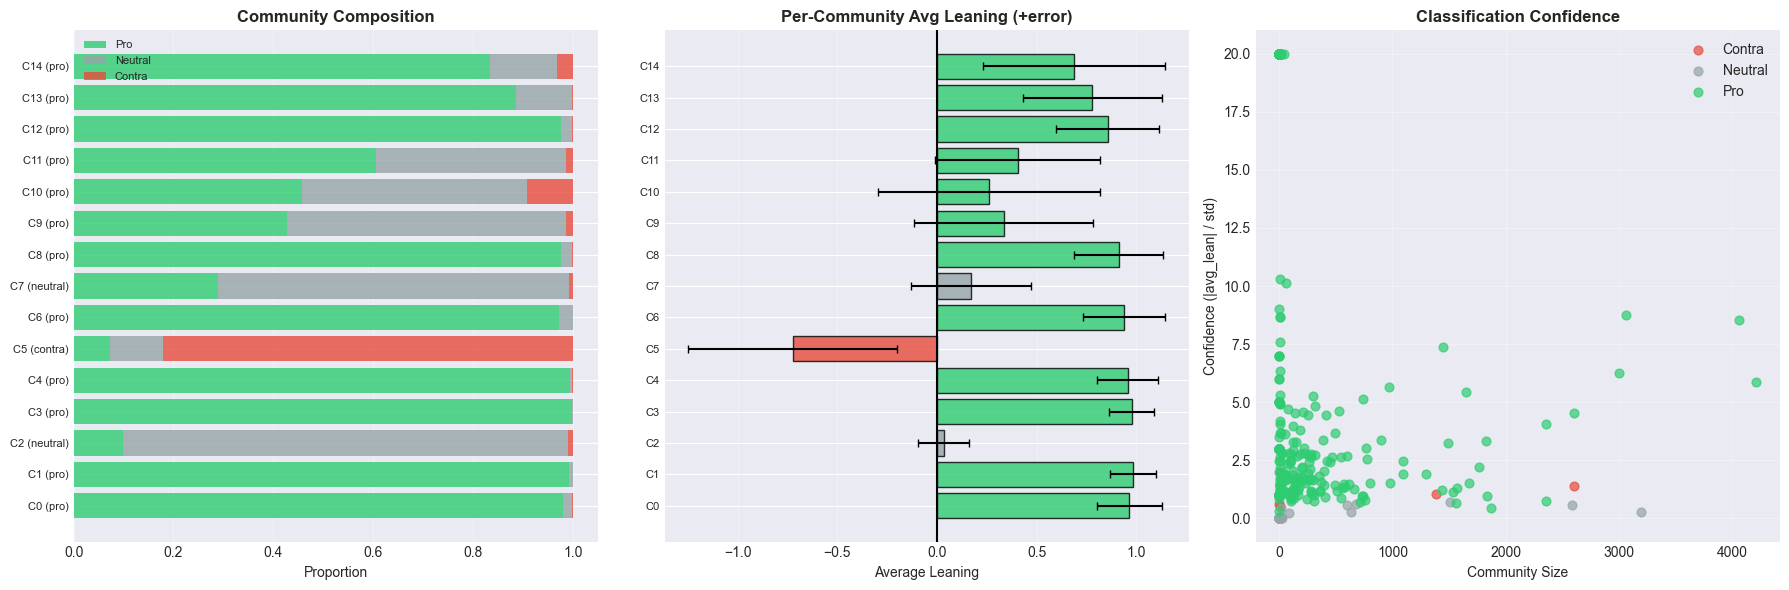

In [68]:
# 10a.2 Detailed Community Classification

def classify_communities_detailed(G, df_users, communities, threshold=0.2, lean_col='lean_scalar'):
    """Classify communities with detailed metrics including composition percentages."""
    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    eps = 1e-12
    comm_members = defaultdict(list)
    for user, cid in communities.items():
        comm_members[cid].append(user)

    results = []
    for cid, members in comm_members.items():
        leanings = [lean_dict.get(u, np.nan) for u in members]
        leanings = [x for x in leanings if not np.isnan(x)]
        if not leanings:
            continue

        avg_lean = float(np.mean(leanings))
        std_lean = float(np.std(leanings))
        med_lean = float(np.median(leanings))

        n_pro = sum(1 for x in leanings if x > threshold)
        n_contra = sum(1 for x in leanings if x < -threshold)
        n_neutral = len(leanings) - n_pro - n_contra
        total = len(leanings)

        stance = 'pro' if avg_lean > threshold else ('contra' if avg_lean < -threshold else 'neutral')

        member_set = set(members)
        internal_edges = external_edges = 0
        for u in members:
            if u not in G: continue
            nbrs = list(G.successors(u)) if isinstance(G, nx.DiGraph) else list(G.neighbors(u))
            for v in nbrs:
                if v in member_set: internal_edges += 1
                else: external_edges += 1

        results.append({
            'community_id': cid, 'size': len(members), 'stance': stance,
            'avg_leaning': avg_lean, 'std_leaning': std_lean, 'median_leaning': med_lean,
            'pct_pro': n_pro/total, 'pct_contra': n_contra/total, 'pct_neutral': n_neutral/total,
            'internal_edges': internal_edges, 'external_edges': external_edges,
            'modularity_contribution': internal_edges / (internal_edges + external_edges + eps),
            'confidence': abs(avg_lean) / (std_lean + eps),
        })

    return pd.DataFrame(results).sort_values('size', ascending=False).reset_index(drop=True)

df_communities_detailed = classify_communities_detailed(G, df_users, communities)

print("=== DETAILED COMMUNITY CLASSIFICATION ===")
print(df_communities_detailed[['community_id', 'size', 'stance', 'avg_leaning', 'std_leaning',
                                'pct_pro', 'pct_contra', 'pct_neutral', 'confidence']].head(15).to_string(index=False))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Stacked bar chart: composition per community
top_n = min(15, len(df_communities_detailed))
top_df = df_communities_detailed.head(top_n)
y_pos = np.arange(top_n)
axes[0].barh(y_pos, top_df['pct_pro'], color='#2ecc71', alpha=0.8, label='Pro')
axes[0].barh(y_pos, top_df['pct_neutral'], left=top_df['pct_pro'], color='#95a5a6', alpha=0.8, label='Neutral')
axes[0].barh(y_pos, top_df['pct_contra'], left=top_df['pct_pro']+top_df['pct_neutral'],
             color='#e74c3c', alpha=0.8, label='Contra')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f"C{int(c)} ({s})" for c, s in zip(top_df['community_id'], top_df['stance'])], fontsize=8)
axes[0].set_xlabel('Proportion')
axes[0].set_title('Community Composition', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')

# 2) Horizontal bar chart: avg_leaning with error bars
colors_lean = ['#2ecc71' if s == 'pro' else ('#e74c3c' if s == 'contra' else '#95a5a6')
               for s in top_df['stance']]
axes[1].barh(y_pos, top_df['avg_leaning'], xerr=top_df['std_leaning'], color=colors_lean,
             alpha=0.8, edgecolor='black', capsize=3)
axes[1].axvline(x=0, color='black', linestyle='-')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"C{int(c)}" for c in top_df['community_id']], fontsize=8)
axes[1].set_xlabel('Average Leaning')
axes[1].set_title('Per-Community Avg Leaning (+error)', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# 3) Confidence vs size scatter
cmap_stance = {'pro': '#2ecc71', 'contra': '#e74c3c', 'neutral': '#95a5a6'}
for stance, group in df_communities_detailed.groupby('stance'):
    axes[2].scatter(group['size'], group['confidence'].clip(0, 20), s=40, alpha=0.7,
                    color=cmap_stance.get(stance, 'gray'), label=stance.capitalize())
axes[2].set_xlabel('Community Size')
axes[2].set_ylabel('Confidence (|avg_lean| / std)')
axes[2].set_title('Classification Confidence', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
# 10b. Central Users -- dengan USERNAME
def identify_central_users(G, df_users, communities, community_stance, top_n=50, lean_col="lean_scalar"):
    print("Computing centrality measures...")
    degree_cent = nx.degree_centrality(G)
    betweenness_cent = nx.betweenness_centrality(G, k=min(500, G.number_of_nodes()))
    pagerank = nx.pagerank(G, max_iter=100)
    try: eigen_cent = nx.eigenvector_centrality(G, max_iter=100)
    except: eigen_cent = pagerank

    lean_dict = dict(zip(df_users['user'], df_users[lean_col]))
    results = {'pro': [], 'contra': [], 'neutral': []}

    for user, comm_id in communities.items():
        if user not in G or user not in lean_dict: continue
        if np.isnan(lean_dict[user]): continue
        stance = community_stance.get(comm_id, 'neutral')
        results[stance].append({
            'username': get_username(user),
            'community_id': comm_id, 'leaning': lean_dict[user],
            'degree_centrality': degree_cent.get(user, 0),
            'betweenness_centrality': betweenness_cent.get(user, 0),
            'pagerank': pagerank.get(user, 0),
            'eigenvector_centrality': eigen_cent.get(user, 0),
            'degree': G.degree(user)
        })

    top_users = {}
    for stance in ['pro', 'contra', 'neutral']:
        if results[stance]:
            d = pd.DataFrame(results[stance])
            for col in ['degree_centrality', 'pagerank', 'betweenness_centrality', 'eigenvector_centrality']:
                mx = d[col].max()
                d[f'{col}_n'] = d[col] / mx if mx > 0 else 0
            d['influence_score'] = (0.3*d['degree_centrality_n'] + 0.3*d['pagerank_n'] +
                                    0.2*d['betweenness_centrality_n'] + 0.2*d['eigenvector_centrality_n'])
            top_users[stance] = d.sort_values('influence_score', ascending=False)
    return top_users

top_users = identify_central_users(G, df_users, communities, community_stance, top_n=50)

for stance in ['pro', 'contra']:
    if stance in top_users and len(top_users[stance]) > 0:
        print(f"\n{'='*70}")
        print(f"TOP 10 INFLUENTIAL USERS - {stance.upper()}")
        print(f"{'='*70}")
        cols = ['username', 'leaning', 'influence_score', 'degree']
        # Filter: hanya user dengan username asli (bukan @ID)
        real = top_users[stance][~top_users[stance]['username'].str.startswith('@')]
        show = real[cols].head(10) if len(real) >= 5 else top_users[stance][cols].head(10)
        print(show.to_string(index=False))

Computing centrality measures...

TOP 10 INFLUENTIAL USERS - PRO
      username  leaning  influence_score  degree
   barengwarga 0.551724         0.880148   12279
     PaltiWest 0.432836         0.660968    7609
   maribasuara 0.400000         0.428548    4614
BudiBukanIntel 0.380102         0.380197    4080
    msaid_didu 0.812500         0.377154    3934
      ilhampid 0.822857         0.320064    6833
  MurtadhaOne1 0.486631         0.304617    3334
       srpablo 0.804469         0.280168    4523
    TGajuk9178 0.708134         0.260156     141
   AntoniusCDN 0.547230         0.258047     245

TOP 10 INFLUENTIAL USERS - CONTRA
      username  leaning  influence_score  degree
     ramaArsy1 1.000000         0.778719    2367
   __adora__aa 0.000000         0.650860    3339
   bambloozled 0.750000         0.001482       8
      fxiryzee 0.000000         0.000932       4
     donjuceyo 0.272727         0.000851       8
     ayustarii 0.714286         0.000851       8
      KQmoomoo 0.6

In [70]:
# 10c. Bridge Users - dengan USERNAME
def analyze_cross_community_bridges(G, communities, community_stance, top_n=20):
    bridge_scores = []
    for user in G.nodes():
        if user not in communities: continue
        user_stance = community_stance.get(communities[user], 'neutral')
        if user_stance == 'neutral': continue
        connections = {'pro': 0, 'contra': 0, 'neutral': 0}
        nbrs = list(G.successors(user)) + list(G.predecessors(user)) if isinstance(G, nx.DiGraph) else list(G.neighbors(user))
        for v in nbrs:
            if v in communities:
                connections[community_stance.get(communities[v], 'neutral')] += 1
        opposite = 'contra' if user_stance == 'pro' else 'pro'
        total = sum(connections.values())
        if total > 0:
            bridge_scores.append({
                'username': get_username(user), 'stance': user_stance,
                'total_connections': total,
                'pro_connections': connections['pro'],
                'contra_connections': connections['contra'],
                'bridge_score': connections[opposite] / total
            })
    return pd.DataFrame(bridge_scores).sort_values('bridge_score', ascending=False).head(top_n)

df_bridges = analyze_cross_community_bridges(G, communities, community_stance, top_n=20)
print("BRIDGE USERS (Connecting Pro <-> Contra)")
if len(df_bridges) > 0:
    print(df_bridges[['username','stance','bridge_score','total_connections']].head(10).to_string(index=False))

BRIDGE USERS (Connecting Pro <-> Contra)
       username stance  bridge_score  total_connections
      ayustarii contra      0.875000                  8
      donjuceyo contra      0.875000                  8
       KQmoomoo contra      0.857143                  7
    bangjeonssi contra      0.833333                  6
    kiraklraito contra      0.833333                  6
 sunnyshinecity contra      0.800000                  5
absencecfthesun contra      0.800000                  5
    friday_0999 contra      0.800000                  5
   caesarianova contra      0.800000                  5
      teakungan contra      0.800000                  5


In [71]:
# 10d. Topic Shifts -- dengan USERNAME
def analyze_topic_shifts(df_raw, user_col='from_id', sentiment_col='calibrated_sentiment', min_posts=10):
    sentiment_map = {'negative': -1, 'neutral': 0, 'positive': 1}
    d = df_raw.copy()
    d['_sn'] = d[sentiment_col].astype(str).str.lower().apply(lambda x: sentiment_map.get(x, 0))
    results = []
    for uid, udf in d.groupby(user_col):
        if len(udf) < min_posts: continue
        sents = udf['_sn'].values
        mid = len(sents) // 2
        early, late = np.mean(sents[:max(mid,1)]), np.mean(sents[max(mid,1):])
        shift = late - early
        shift_type = 'stable'
        if abs(shift) > 0.3:
            if shift > 0 and early < -0.2 and late > 0.2: shift_type = 'contra_to_pro'
            elif shift < 0 and early > 0.2 and late < -0.2: shift_type = 'pro_to_contra'
            elif shift > 0: shift_type = 'negative_to_positive'
            elif shift < 0: shift_type = 'positive_to_negative'
        results.append({'username': get_username(uid), 'n_posts': len(udf),
                        'early_sentiment': early, 'late_sentiment': late,
                        'sentiment_shift': shift, 'shift_type': shift_type,
                        'shift_magnitude': abs(shift)})
    return pd.DataFrame(results)

df_shifts = analyze_topic_shifts(df, user_col='from_id', sentiment_col='calibrated_sentiment')
print(f"Users analyzed: {len(df_shifts):,}")
print(f"Significant shifts (> 0.3): {(df_shifts['shift_magnitude'] > 0.3).sum():,}")
print(f"\n{df_shifts['shift_type'].value_counts()}")

Users analyzed: 5,442
Significant shifts (> 0.3): 1,784

shift_type
stable                  3658
positive_to_negative     956
negative_to_positive     765
pro_to_contra             57
contra_to_pro              6
Name: count, dtype: int64


---
## 11. Visualisasi Komprehensif

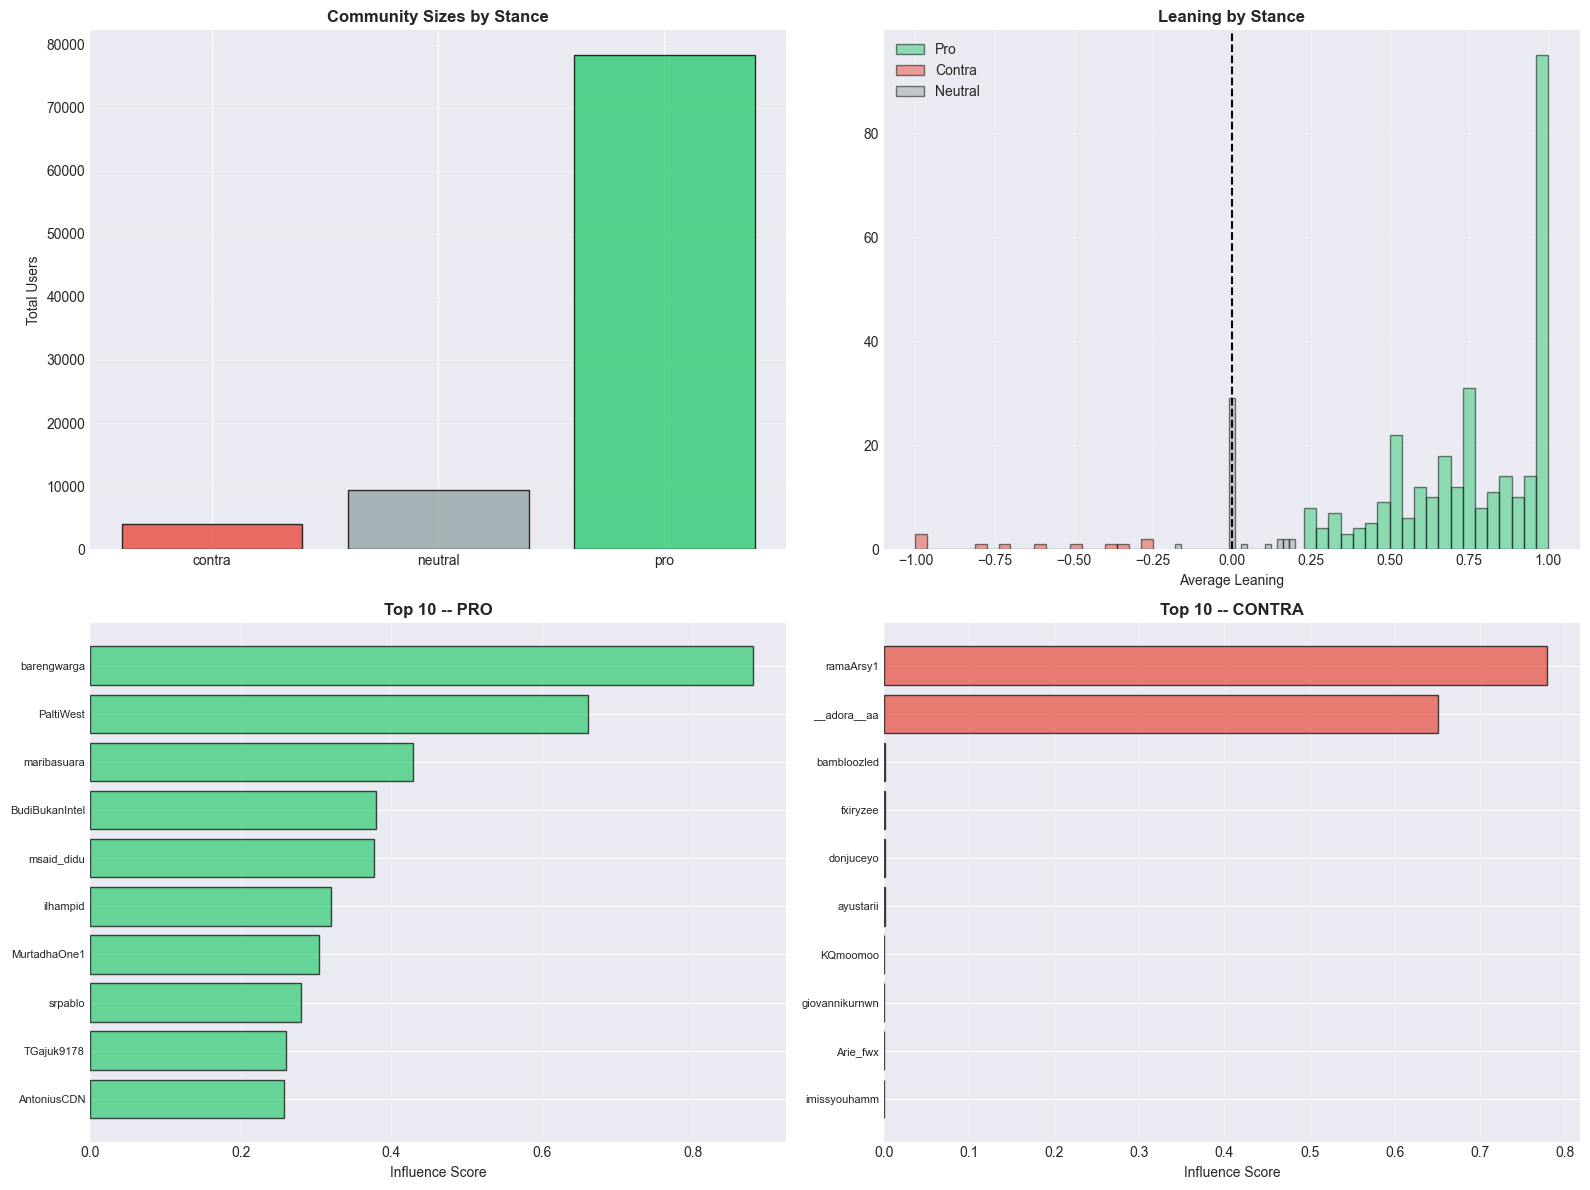

Saved: 06_pro_contra.png


In [72]:
# 11a. Pro vs Contra
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
stance_sizes = df_communities.groupby('stance')['size'].sum()
cmap_colors = {'pro': '#2ecc71', 'contra': '#e74c3c', 'neutral': '#95a5a6'}
axes[0,0].bar(stance_sizes.index, stance_sizes.values,
              color=[cmap_colors.get(s,'gray') for s in stance_sizes.index], alpha=0.8, edgecolor='black')
axes[0,0].set_ylabel('Total Users')
axes[0,0].set_title('Community Sizes by Stance', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='y')

for st, c in cmap_colors.items():
    sd = df_communities[df_communities['stance']==st]
    if len(sd) > 0:
        axes[0,1].hist(sd['avg_leaning'], bins=20, alpha=0.5, label=st.capitalize(), color=c, edgecolor='black')
axes[0,1].axvline(x=0, color='black', linestyle='--')
axes[0,1].set_xlabel('Average Leaning')
axes[0,1].set_title('Leaning by Stance', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

for i, (stance, color) in enumerate([('pro', '#2ecc71'), ('contra', '#e74c3c')]):
    ax = axes[1, i]
    if stance in top_users and len(top_users[stance]) > 0:
        # Filter: hanya user dengan username asli (bukan @ID)
        _f = top_users[stance][~top_users[stance]['username'].str.startswith('@')]
        dp = _f.head(10).copy() if len(_f) >= 5 else top_users[stance].head(10).copy()
        y = np.arange(len(dp))
        ax.barh(y, dp['influence_score'].values, color=color, alpha=0.7, edgecolor='black')
        ax.set_yticks(y)
        ax.set_yticklabels([str(u) for u in dp['username'].values], fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Influence Score')
        ax.set_title(f'Top 10 -- {stance.upper()}', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('06_pro_contra.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_pro_contra.png")

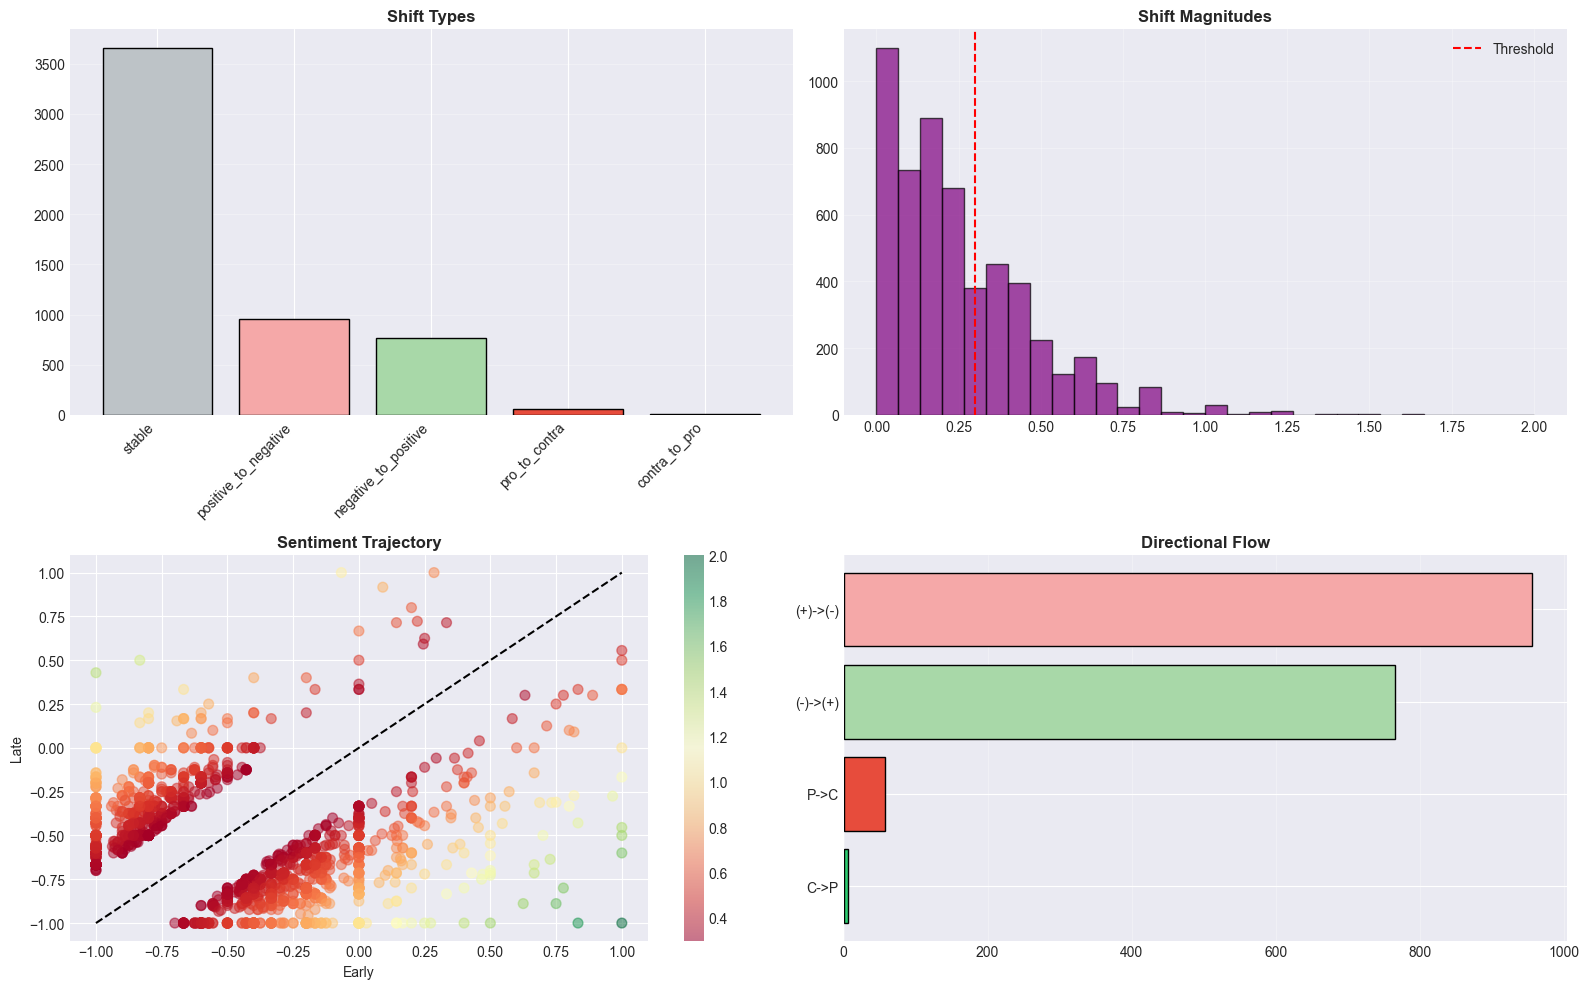

In [73]:
# 11b. Topic Shifts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
shift_counts = df_shifts['shift_type'].value_counts()
sc_colors = {'contra_to_pro':'#2ecc71','pro_to_contra':'#e74c3c','negative_to_positive':'#a8d8a8','positive_to_negative':'#f5a8a8','stable':'#bdc3c7'}
axes[0,0].bar(range(len(shift_counts)), shift_counts.values, color=[sc_colors.get(s,'gray') for s in shift_counts.index], edgecolor='black')
axes[0,0].set_xticks(range(len(shift_counts))); axes[0,0].set_xticklabels(shift_counts.index, rotation=45, ha='right')
axes[0,0].set_title('Shift Types', fontweight='bold'); axes[0,0].grid(True, alpha=0.3, axis='y')

axes[0,1].hist(df_shifts['shift_magnitude'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0,1].axvline(x=0.3, color='r', linestyle='--', label='Threshold'); axes[0,1].set_title('Shift Magnitudes', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

sig = df_shifts[df_shifts['shift_magnitude']>0.3]
if len(sig) > 0:
    sc = axes[1,0].scatter(sig['early_sentiment'], sig['late_sentiment'], alpha=0.5, s=50, c=sig['shift_magnitude'], cmap='RdYlGn')
    axes[1,0].plot([-1,1],[-1,1],'k--'); axes[1,0].set_xlabel('Early'); axes[1,0].set_ylabel('Late')
    axes[1,0].set_title('Sentiment Trajectory', fontweight='bold'); plt.colorbar(sc, ax=axes[1,0])

flow = {'C->P': (df_shifts['shift_type']=='contra_to_pro').sum(), 'P->C': (df_shifts['shift_type']=='pro_to_contra').sum(),
        '(-)->(+)': (df_shifts['shift_type']=='negative_to_positive').sum(), '(+)->(-)': (df_shifts['shift_type']=='positive_to_negative').sum()}
axes[1,1].barh(list(flow.keys()), list(flow.values()), color=['#2ecc71','#e74c3c','#a8d8a8','#f5a8a8'], edgecolor='black')
axes[1,1].set_title('Directional Flow', fontweight='bold'); axes[1,1].grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.savefig('07_shifts.png', dpi=150, bbox_inches='tight'); plt.show()

Visualizing top-500 degree subgraph: 500 nodes, 5647 edges


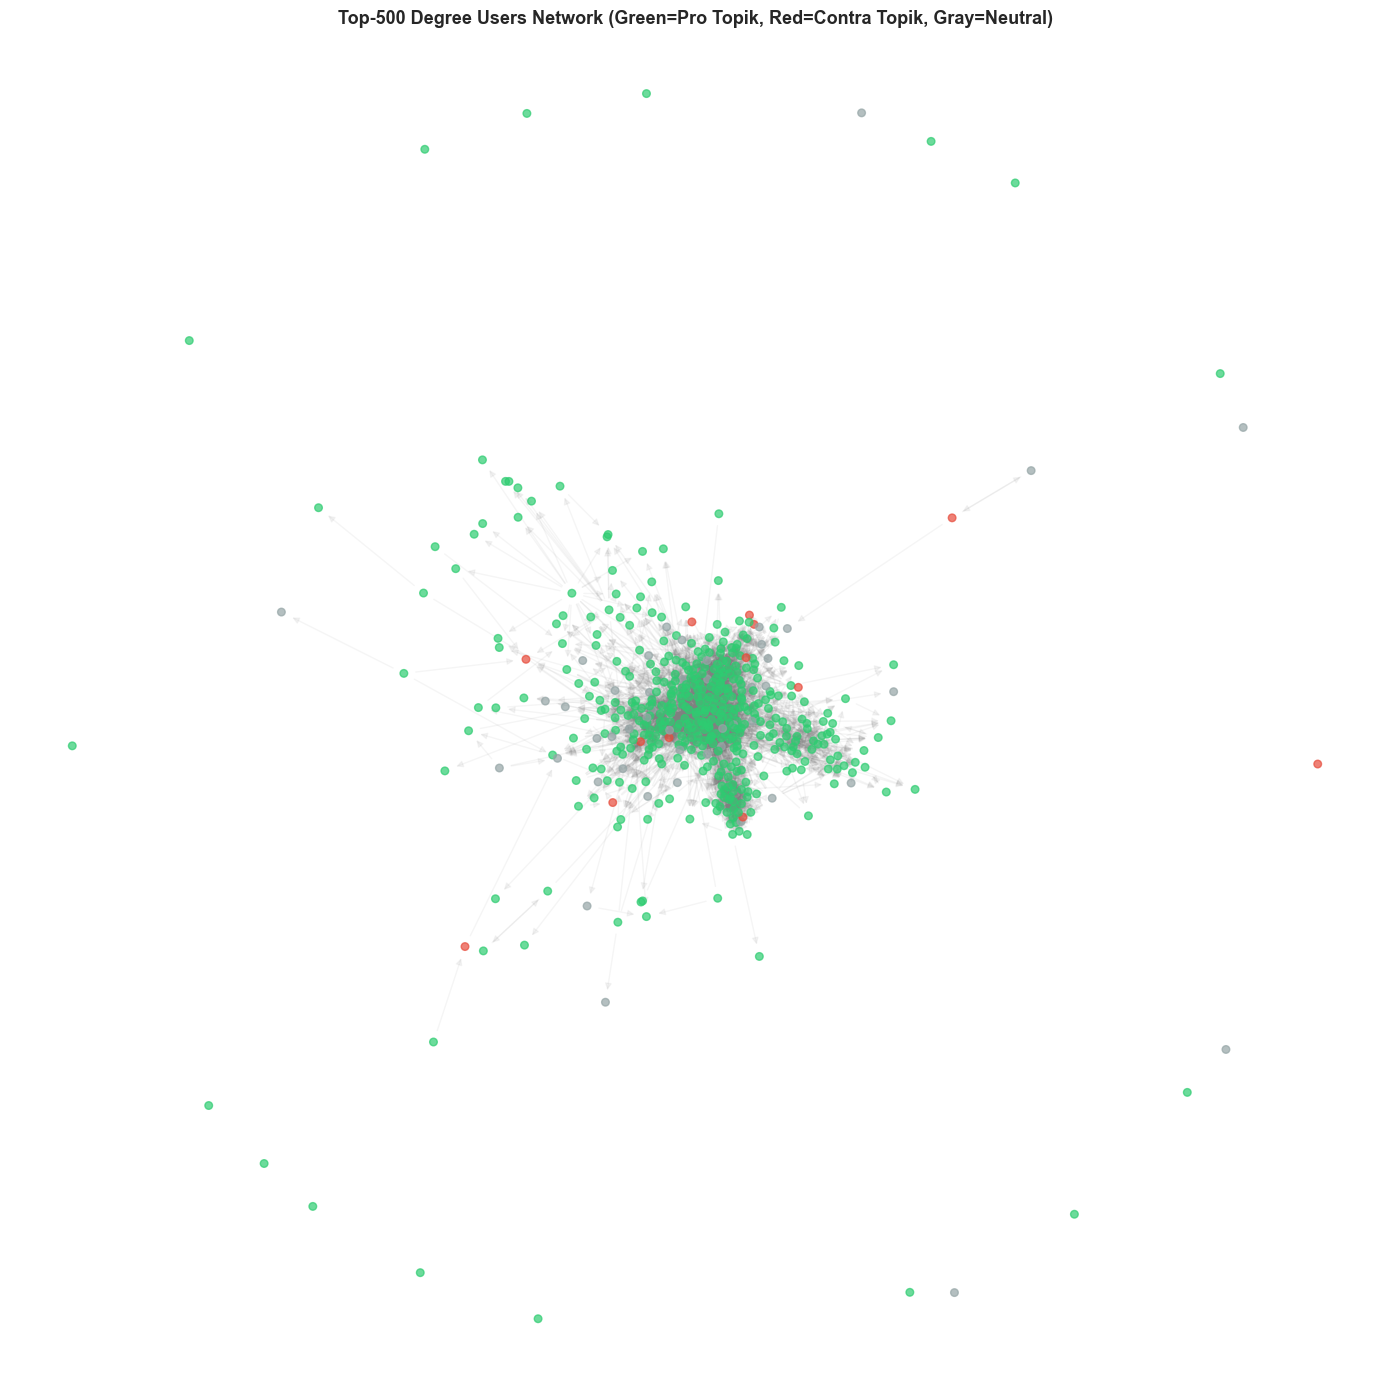

In [74]:
# 11c. Network graph
MAX_VIS = 500

degree_dict = dict(G.degree())
top_degree_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:MAX_VIS]
G_vis = G.subgraph(top_degree_nodes).copy()

print(f"Visualizing top-{MAX_VIS} degree subgraph: {G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges")

lean_dict = dict(zip(df_users["user"], df_users["lean_scalar"]))

fig, ax = plt.subplots(figsize=(14, 14))
pos = nx.spring_layout(G_vis, seed=42, k=2.0/np.sqrt(G_vis.number_of_nodes()+1), iterations=80)

node_colors = []
for n in G_vis.nodes():
    l = lean_dict.get(n, 0)
    if l > 0.2: node_colors.append('#2ecc71')
    elif l < -0.2: node_colors.append('#e74c3c')
    else: node_colors.append('#95a5a6')

nx.draw_networkx_edges(G_vis, pos, alpha=0.08, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G_vis, pos, node_color=node_colors, node_size=30, alpha=0.7, ax=ax)
ax.set_title(f'Top-{MAX_VIS} Degree Users Network (Green=Pro Topik, Red=Contra Topik, Gray=Neutral)', fontweight='bold', fontsize=13)
ax.axis('off')
plt.tight_layout(); plt.savefig('08_network.png', dpi=150, bbox_inches='tight'); plt.show()

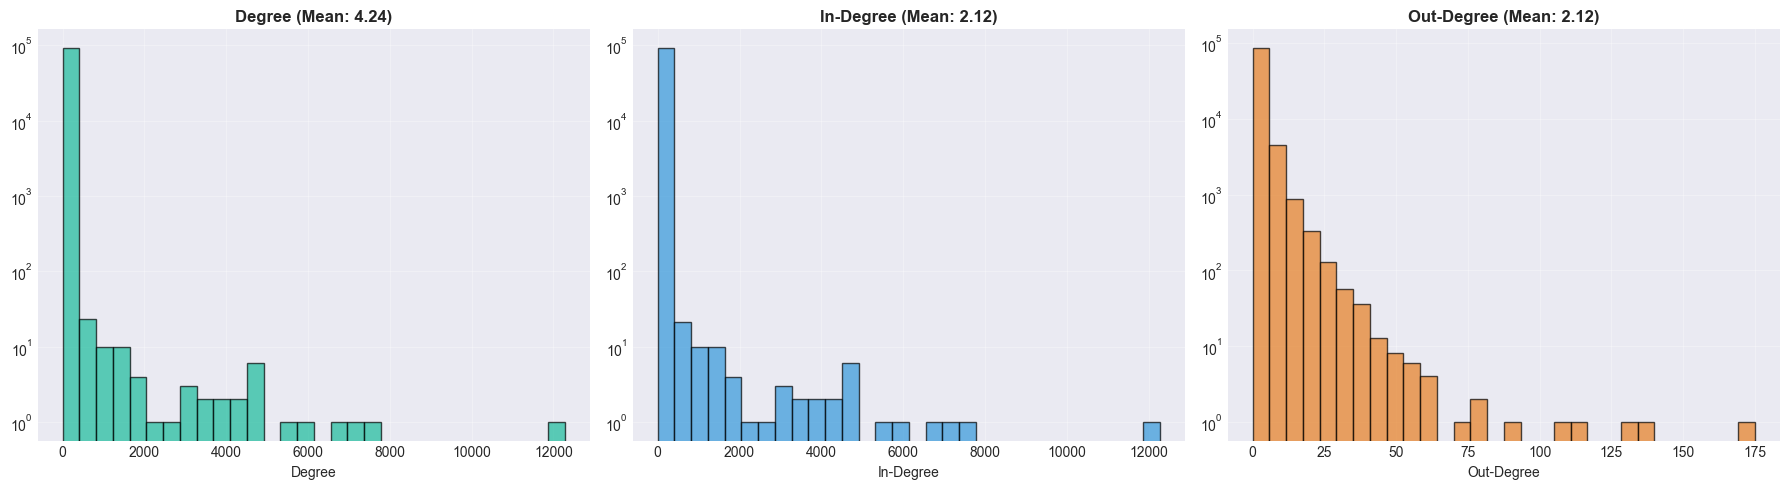

In [75]:
# 11d. Degree analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
degs = [G.degree(n) for n in G.nodes()]
in_degs = [G.in_degree(n) for n in G.nodes()]
out_degs = [G.out_degree(n) for n in G.nodes()]

for ax, data_arr, title, color in [(axes[0], degs, 'Degree', '#1abc9c'), (axes[1], in_degs, 'In-Degree', '#3498db'), (axes[2], out_degs, 'Out-Degree', '#e67e22')]:
    ax.hist(data_arr, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel(title); ax.set_title(f'{title} (Mean: {np.mean(data_arr):.2f})', fontweight='bold')
    ax.set_yscale('log'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('09_degrees.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 12. Summary Report

In [76]:
print(f"""
{'='*80}
ECHO CHAMBER RATIO (ECR 2.0) -- COMPLETE ANALYSIS REPORT
{'='*80}
Topik: 'Indonesia Gelap'
Pro   = SETUJU Indonesia Gelap (sentimen negatif dominan) -> lean_scalar > 0
Contra = TIDAK SETUJU Indonesia Gelap (sentimen positif dominan) -> lean_scalar < 0

DATASET OVERVIEW
{'-'*80}
  Total Records          : {len(df):,}
  Unique Users (content) : {df['from_id'].nunique():,}
  Users in Network       : {n_nodes:,}
  Total Interactions     : {n_edges:,}
  Network Density        : {density:.6f}

CALIBRATION (Cross-Validated)
{'-'*80}
  Best Method            : {best_method}
  Metode dibandingkan    : Uncalibrated, Isotonic(CV), Sigmoid(CV), Temperature
  ECE (before)           : {uncal_metrics['ece']:.4f}
  ECE (after)            : {cal_comparison.loc[cal_comparison['ece'].idxmin(), 'ece']:.4f}
  Sentimen berubah       : {df['sentiment_changed'].sum():,} ({100*df['sentiment_changed'].mean():.2f}%)
  Confidence (before)    : {df['sentiment_confidence_level'].mean():.4f}
  Confidence (after)     : {df['calibrated_confidence'].mean():.4f}

COMMUNITY DETECTION
{'-'*80}
  Algorithm              : {'Leiden' if _HAS_LEIDEN else 'Louvain'}
  Resolution             : {resolution:.3f}
  Communities Found      : {n_communities}
  Pro Communities        : {stance_counts.get('pro', 0)}
  Contra Communities     : {stance_counts.get('contra', 0)}
  Neutral Communities    : {stance_counts.get('neutral', 0)}

ECR 2.0 RESULTS
{'-'*80}
  Intra-community Agr.   : {ecr2.intra:.4f}
  Inter-community Agr.   : {ecr2.inter:.4f}
  ECR Ratio (Agreement)  : {ecr2.ratio:.4f}
  ECR Ratio (Cosine)     : {ecr_cosine:.4f}
  Homophily (Pearson r)  : {ecr2.homophily_r:.4f}
  Empirical Threshold    : {threshold:.4f}

  * KESIMPULAN: {classification}

DIFFUSION BIAS
{'-'*80}
  Regression slope       : {slope:.4f} (p={p_value:.2e})
  R²                     : {r_value**2:.4f}
  Bias Ratio             : {bias_ratio:.4f}
  Paired t-test          : t={t_stat:.4f}, p={t_pvalue:.2e}
  Cohen's d              : {cohens_d:.4f}

TOPIC SHIFTS
{'-'*80}
  Users Analyzed         : {len(df_shifts):,}
  Significant Shifts     : {(df_shifts['shift_magnitude'] > 0.3).sum():,}
  Contra -> Pro          : {(df_shifts['shift_type'] == 'contra_to_pro').sum():,}
  Pro -> Contra          : {(df_shifts['shift_type'] == 'pro_to_contra').sum():,}
""")


ECHO CHAMBER RATIO (ECR 2.0) -- COMPLETE ANALYSIS REPORT
Topik: 'Indonesia Gelap'
Pro   = SETUJU Indonesia Gelap (sentimen negatif dominan) -> lean_scalar > 0
Contra = TIDAK SETUJU Indonesia Gelap (sentimen positif dominan) -> lean_scalar < 0

DATASET OVERVIEW
--------------------------------------------------------------------------------
  Total Records          : 338,436
  Unique Users (content) : 116,675
  Users in Network       : 91,784
  Total Interactions     : 194,491
  Network Density        : 0.000023

CALIBRATION (Cross-Validated)
--------------------------------------------------------------------------------
  Best Method            : isotonic
  Metode dibandingkan    : Uncalibrated, Isotonic(CV), Sigmoid(CV), Temperature
  ECE (before)           : 0.2413
  ECE (after)            : 0.0000
  Sentimen berubah       : 6 (0.00%)
  Confidence (before)    : 0.6363
  Confidence (after)     : 1.0000

COMMUNITY DETECTION
------------------------------------------------------------

In [77]:
text_col = None
for candidate in ['cleaned_text', 'full_text', 'text', 'content', 'tweet']:
    if candidate in df.columns:
        text_col = candidate
        break

# Export all results
from pathlib import Path
output_dir = Path("ecr_analysis_results")
output_dir.mkdir(exist_ok=True)

# Users with communities
df_users_export = df_users.copy()
df_users_export['username'] = df_users_export['user'].apply(get_username)
df_users_export['community'] = df_users_export['user'].map(communities)
df_users_export['stance'] = df_users_export['community'].map(community_stance)
df_users_export.to_csv(output_dir / 'users_with_communities.csv', index=False)

# Community summaries (both basic and detailed)
df_communities.to_csv(output_dir / 'community_summary.csv', index=False)
df_communities_detailed.to_csv(output_dir / 'community_detailed.csv', index=False)

# Topic shifts
df_shifts.to_csv(output_dir / 'topic_shifts.csv', index=False)

# Top users per stance
for st in ['pro', 'contra']:
    if st in top_users:
        top_users[st].to_csv(output_dir / f'top_{st}_users.csv', index=False)

# Bridge users
df_bridges.to_csv(output_dir / 'bridge_users.csv', index=False)

# Diffusion results
ic_rows.to_csv(output_dir / 'diffusion_results.csv', index=False)
df_diff_comm.to_csv(output_dir / 'diffusion_per_community.csv', index=False)

# Calibration comparison
cal_comparison.to_csv(output_dir / 'calibration_comparison.csv', index=False)

# ECR metrics (enhanced)
with open(output_dir / "ecr_metrics.txt", "w", encoding="utf-8") as f:
    f.write(f"ECR Ratio (Agreement): {ecr2.ratio:.4f}\n")
    f.write(f"ECR Ratio (Cosine):    {ecr_cosine:.4f}\n")
    f.write(f"Intra (Agreement):     {ecr2.intra:.4f}\n")
    f.write(f"Inter (Agreement):     {ecr2.inter:.4f}\n")
    f.write(f"Intra (Cosine):        {intra_cosine:.4f}\n")
    f.write(f"Inter (Cosine):        {inter_cosine:.4f}\n")
    f.write(f"Homophily:             {ecr2.homophily_r:.4f}\n")
    f.write(f"Threshold:             {threshold:.4f}\n")
    f.write(f"Classification:        {classification}\n")
    f.write(f"\nCalibration: {best_method}\n")
    f.write(f"ECE (before): {uncal_metrics['ece']:.4f}\n")
    f.write(f"ECE (after):  {cal_comparison.loc[cal_comparison['ece'].idxmin(), 'ece']:.4f}\n")
    f.write(f"\nDiffusion Bias:\n")
    f.write(f"  slope={slope:.4f}, R²={r_value**2:.4f}, p={p_value:.2e}\n")
    f.write(f"  bias_ratio={bias_ratio:.4f}\n")
    f.write(f"  t-test: t={t_stat:.4f}, p={t_pvalue:.2e}\n")
    f.write(f"  Cohen's d={cohens_d:.4f}\n")

# Sentiment comparison (if available)
if text_col is not None:
    df_eval.to_csv(output_dir / 'sentiment_comparison.csv', index=False)

print("Semua hasil tersimpan di ecr_analysis_results/")
print(f"Files: {[f.name for f in output_dir.iterdir()]}")

Semua hasil tersimpan di ecr_analysis_results/
Files: ['bridge_users.csv', 'calibration_comparison.csv', 'community_detailed.csv', 'community_summary.csv', 'diffusion_per_community.csv', 'diffusion_results.csv', 'ecr_metrics.txt', 'sentiment_comparison.csv', 'topic_shifts.csv', 'top_contra_users.csv', 'top_pro_users.csv', 'users_with_communities.csv']


In [ ]:
import nbformat
from nbconvert import PythonExporter

input_file = "ECR2_Full_Pipeline.ipynb"
output_file = "ECR2_Full_Pipeline.py"

with open(input_file, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

exporter = PythonExporter()
source, _ = exporter.from_notebook_node(nb)

with open(output_file, "w", encoding="utf-8") as f:
    f.write(source)

print("Convert berhasil:", output_file)